In [1]:
import os
import gc
import glob
import json
#import h5py
import numpy as np
import pickle
import pandas as pd
#from IPython.display import Audio, display
from collections import Counter, defaultdict
from pynwb import NWBHDF5IO
from datetime import datetime
import scipy.signal
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

In [2]:
from extract_features import extractHG, stackFeatures, downsampleLabels
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
#from feature_vizualizer import PhonemeFeatureVisualizer
from markov_phoneme_model import MarkovPhonemeModel
from extract_features import extractHG, downsampleLabels, extractMelSpecs
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [3]:
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic 
from dataset_config import Dutch30Config

from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch

In [4]:
dutch30_dir = DUTCH_30_PATH

# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))

In [5]:
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [6]:
extractor = Dutch30FeatureExtractor()

pipeline = Dutch30Pipeline(
        dutch30_extractor=extractor,
        debug_mode=False,
        pca_components= None, #100,
        feature_extraction_method = 'high_gamma',# 'high_gamma', #'band_powers', #'band_power_hjorth', # 'hjorth', #'band_powers',# 'hjorth', #'high_gamma', # 'band_powers', # 'band_power_hjorth'
        use_rms_boundaries=False,   
        use_multifeature=False,
        use_wav2vec=True,
        subtract_baseline=False,
        #baseline_method = 'band_powers' #'feature_matched', 'band_powers', 'raw'
    )

sample_fraction = 1
patient_range = (1,30)

# Try to load checkpoint
print(f"Attempting to load checkpoint (sample_fraction={sample_fraction})...")
    
if pipeline.try_load_checkpoint(sample_fraction=sample_fraction):
    print(f"Checkpoint loaded successfully!")
    print(f"  Train samples: {len(pipeline.train.get('features', []))}")
    print(f"  Test samples: {len(pipeline.test.get('features', []))}")
    
else: # No checkpoint found - run all steps
    print(f"No checkpoint found. Running pipeline steps...")
    
    print(f"\n  Step 1: Loading data (patients {patient_range})...")

    # Load pre-trained wav2vec model
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
    model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", use_safetensors=True)
    config = Dutch30Config()
    extractor = Dutch30FeatureExtractor()
    pipeline.step1_load_dutch30_data(patient_range=(1,30))
    pipeline.split_result = None
    pipeline.step2_split_by_instances();
    pipeline.print_channel_counts()
    pipeline.step3_load_channel_exclusions('channel_exclusions.json')
    pipeline.apply_channel_exclusions()
    pipeline.print_channel_counts()
    pipeline.step4_custom_detector()
    pipeline.step5_accumulate_data_dutch30()
    pipeline.step5b_normalize_lengths(target_frames=10, use_augmentation=True, balance_classes=True, n_chunks=5)
    #pipeline.step5b_normalize_lengths(target_frames=10, use_augmentation=False, balance_classes=True, n_chunks=5)
    pipeline.dutch30_step6_resolve_unknowns()
    pipeline.checkpoint_after_step6(sample_fraction=sample_fraction)
    pipeline.step7_filter_unknowns(unknown_keep_ratio=0.0025);
    

    print(f"  Train samples: {len(pipeline.train.get('features', []))}")
    print(f"  Test samples: {len(pipeline.test.get('features', []))}")   

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=None, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=None, g

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully
Attempting to load checkpoint (sample_fraction=1)...
UnifiedPhonemePipeline: No checkpoint found for high_gamma, PCA=None, sample=1
No checkpoint found. Running pipeline steps...

  Step 1: Loading data (patients (1, 30))...
Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
UnifiedPhonemePipeline: Step 1: Loading Dutch30...
UnifiedPhonemePipeline:   Using patients P01 to P30: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline: P01: 70 train, 31 test, baseline: (130,)
UnifiedPhonemePipeline: P02: 68 train, 33 test, b

C:\ProgramData\anaconda3\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


AcousticChangeDetector: Wav2vec model initialized successfully
UnifiedPhonemePipeline: 
Step 5 starting:
UnifiedPhonemePipeline:   Train patients: ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
UnifiedPhonemePipeline:   Available samples: train=4828, test=2484
AcousticChangeDetector: Processing 4828 instances in 19 batches (no replacement)
AcousticChangeDetector: Processing batch 1/19
          Building batch from 256 instances...
          Batch built: 256 words
          Processing batch (phoneme detection)...
AcousticChangeDetector:   Need 10 peaks but only found 5 for word 'zevenduizend' (Patient P01)
AcousticChangeDetector:   Need 10 peaks but only found 9 for word 'vogelkooitje' (Patient P01)
AcousticChangeDetector:   Need 12 peaks but only found 11 for word 'teruggekregen' (Patient P01)
AcousticChangeDetector:   Need 6 peaks but only foun

In [ ]:
# #check where method is used
# import os

# search_term = "standardize_channels"
# project_path = r"D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch_step2"

# for filename in os.listdir(project_path):
#     if filename.endswith('.py'):
#         filepath = os.path.join(project_path, filename)
#         with open(filepath, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             for line_num, line in enumerate(lines, 1):
#                 if search_term in line and 'def ' not in line and not line.strip().startswith('#'):
#                     print(f"{filename}:{line_num}: {line.strip()}")

In [ ]:
# diag = Dutch30PhonemeDetectionDiagnostic(pipeline)
# diag.visualize_word_analysis('P23', word_name = 'postzegelverzameling.', save_path='p23_word_postzegelverzameling.png')

In [ ]:
#diag.visualize_multifeature_analysis('P01', word_index=50)
# diag.visualize_rms_boundaries('P01',  word_name = 'vogelkooitje')

In [ ]:
# Quick check first 10 words
# diag.batch_diagnostic('sub-p11', num_samples=5)

In [7]:
# Experiment logger
import json
import os
from datetime import datetime
import numpy as np


PATIENT_GROUPS = {
    'P01-P10': ['P01', 'P02', 'P03', 'P04', 'P06', 'P07', 'P08', 'P09', 'P10'],
    'P11-P20': ['P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P20'],
    'P21-P30': ['P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30'],
}


def run_experiment(pipeline, order=3, class_weight='balanced', use_groups=False,
                   classifier_type='random_forest', use_viterbi=False):
    """
    Run a single experiment with given parameters.
    Returns experiment name, params dict, and per-patient results dict.

    Args:
        pipeline: Pipeline with train/test data.
        order: Markov chain order.
        class_weight: 'balanced', 'balanced_subsample', or None.
        use_groups: Whether to use phoneme groups.
        classifier_type: 'random_forest', 'extra_trees', etc.
        use_viterbi: Whether to use Viterbi decoding.

    Returns:
        Tuple of (name, params, results).
    """
    from markov_phoneme_model import MarkovPhonemeModel

    # Build name automatically from parameters
    weight_str = str(class_weight) if class_weight else 'none'
    name = f"{classifier_type}_o{order}_w{weight_str}"
    if use_viterbi:
        name += "_viterbi"

    params = {
        'order': order,
        'class_weight': str(class_weight),
        'use_groups': use_groups,
        'classifier_type': classifier_type,
        'use_viterbi': use_viterbi,
    }

    print(f"\nRunning: {name}")
    print(f"  Params: {params}")

    results = {}
    for pid in sorted(set(pipeline.train['phoneme_participant_ids'])):
        train_mask = [p == pid for p in pipeline.train['phoneme_participant_ids']]
        test_mask = [p == pid for p in pipeline.test['phoneme_participant_ids']]
        train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
        train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
        test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
        test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]

        if len(train_feat) < 10 or len(test_feat) < 5:
            continue

        model = MarkovPhonemeModel(
            phonetic_dict=pipeline.detector.phonetic_dict,
            order=order,
            use_groups=use_groups,
            class_weight=class_weight,
            classifier_type=classifier_type,
        )
        model.train(features=train_feat, phoneme_labels=train_labels)

        preds, _ = model.predict(test_feat, use_viterbi=use_viterbi)
        correct = sum(1 for p, t in zip(preds, test_labels) if p == t)
        accuracy = correct / len(test_labels)

        results[pid] = {
            'accuracy': accuracy,
            'train_size': len(train_feat),
            'test_size': len(test_feat),
            'n_classes': len(set(train_labels)),
            'predictions': preds,
            'true_labels': test_labels,
            'model': model,
        }

    return name, params, results


class ExperimentLogger:
    """
    Simple experiment logger that stores a flat CSV-like table.

    Each row = one experiment.
    Columns = experiment name, params, per-patient accuracies, group means.
    """

    def __init__(self, log_file='experiments.json'):
        """
        Initialize the experiment logger.

        Args:
            log_file: Path to JSON file for storing experiments.
        """
        self.log_file = log_file
        self.experiments = []

        if os.path.exists(log_file):
            with open(log_file, 'r') as f:
                self.experiments = json.load(f)
            print(f"Loaded {len(self.experiments)} previous experiments from {log_file}")

    def log(self, name, params, results):
        """
        Log an experiment from run_experiment output.

        Args:
            name: Experiment name (auto-generated by run_experiment).
            params: Dict of parameters.
            results: Dict of per-patient results from run_experiment.
        """
        # Extract only accuracies per patient (no model objects)
        patient_accs = {}
        for pid, pr in results.items():
            patient_accs[pid] = round(pr['accuracy'], 4)

        # Compute group means
        group_means = {}
        for group_name, patients in PATIENT_GROUPS.items():
            accs = [patient_accs[pid] for pid in patients if pid in patient_accs]
            if accs:
                group_means[group_name] = round(np.mean(accs), 4)
            else:
                group_means[group_name] = None

        all_accs = list(patient_accs.values())
        overall = round(np.mean(all_accs), 4) if all_accs else 0

        entry = {
            'name': name,
            'timestamp': datetime.now().isoformat()[:19],
            'params': params,
            'patients': patient_accs,
            'group_means': group_means,
            'overall': overall,
        }

        self.experiments.append(entry)

        with open(self.log_file, 'w') as f:
            json.dump(self.experiments, f, indent=2)

        print(f"  Saved: {name} (overall={overall})")

    def print_table(self, last_n=None):
        """
        Print a simple comparison table.

        Args:
            last_n: Show last N experiments (None = all).
        """
        experiments = self.experiments[-last_n:] if last_n else self.experiments

        if not experiments:
            print("No experiments.")
            return

        # Collect all patient IDs
        all_patients = set()
        for exp in experiments:
            all_patients.update(exp['patients'].keys())

        # Print header
        exp_names = [exp['name'][:20] for exp in experiments]
        header_width = max(10, max(len(n) for n in exp_names) + 2)

        print("\n" + "=" * (12 + header_width * len(experiments)))
        row = f"{'Patient':<12}"
        for name in exp_names:
            row += f"{name:<{header_width}}"
        print(row)
        print("-" * (12 + header_width * len(experiments)))

        # Print by group
        for group_name, patients in PATIENT_GROUPS.items():
            group_patients = [p for p in patients if p in all_patients]
            if not group_patients:
                continue

            for pid in group_patients:
                row = f"  {pid:<10}"
                for exp in experiments:
                    acc = exp['patients'].get(pid)
                    if acc is not None:
                        row += f"{acc:<{header_width}.4f}"
                    else:
                        row += f"{'N/A':<{header_width}}"
                print(row)

            # Group mean
            row = f"  {'MEAN':<10}"
            for exp in experiments:
                gm = exp['group_means'].get(group_name)
                if gm is not None:
                    row += f"{gm:<{header_width}.4f}"
                else:
                    row += f"{'N/A':<{header_width}}"
            print(row)
            print()

        # Overall
        print("-" * (12 + header_width * len(experiments)))
        row = f"{'OVERALL':<12}"
        for exp in experiments:
            row += f"{exp['overall']:<{header_width}.4f}"
        print(row)
        print("=" * (12 + header_width * len(experiments)))

    def clear(self):
        """Clear all experiments."""
        confirm = input(f"Delete all {len(self.experiments)} experiments? (yes/no): ")
        if confirm.lower() == 'yes':
            self.experiments = []
            if os.path.exists(self.log_file):
                os.remove(self.log_file)
            print("Cleared.")

    def remove_last(self, n=1):
        """
        Remove last N experiments.

        Args:
            n: Number of experiments to remove from the end.
        """
        removed = self.experiments[-n:]
        self.experiments = self.experiments[:-n]
        with open(self.log_file, 'w') as f:
            json.dump(self.experiments, f, indent=2)
        for exp in removed:
            print(f"  Removed: {exp['name']}")

In [8]:
def train_and_evaluate(pipeline, use_groups=False, order=3, class_weight='balanced', 
                       classifier_type='random_forest'):
    """Train per patient and return results."""
    from collections import Counter
    
    results = {}
    for pid in sorted(set(pipeline.train['phoneme_participant_ids'])):
        # Filter data
        train_mask = [p == pid for p in pipeline.train['phoneme_participant_ids']]
        test_mask = [p == pid for p in pipeline.test['phoneme_participant_ids']]
        train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
        train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
        test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
        test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
        
        if len(train_feat) < 10 or len(test_feat) < 5:
            continue
        
        # Train model with passed parameters
        model = MarkovPhonemeModel(
            phonetic_dict=pipeline.detector.phonetic_dict,
            order=order,
            use_groups=use_groups,
            class_weight=class_weight,
            classifier_type=classifier_type  # ADD THIS
        )
        model.train(features=train_feat, phoneme_labels=train_labels)
        
        # Predict and calculate accuracy
        preds, _ = model.predict(test_feat, use_viterbi=True)
        correct = sum(1 for p, t in zip(preds, test_labels) if p == t)
        accuracy = correct / len(test_labels)
        
        results[pid] = {
            'model': model,
            'accuracy': accuracy,
            'train_size': len(train_feat),
            'test_size': len(test_feat),
            'n_classes': len(set(train_labels)),
            'predictions': preds,
            'true_labels': test_labels
        }
        print(f"  {pid}: Acc={accuracy:.3f} ({len(set(train_labels))} classes)")
    
    accs = [r['accuracy'] for r in results.values()]
    print(f"\n  Mean: {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
    return results

In [9]:
def visualize_patient_model(pid, patient_results, pipeline, show_table=True):
    """
    Detailed analysis for one patient.
    
    Args:
        pid: Patient ID
        patient_results: Results dict from train_and_evaluate
        pipeline: Pipeline with train/test data
        show_table: Whether to print per-phoneme accuracy table
    """
    from sklearn.metrics import confusion_matrix, precision_score, recall_score
    from matplotlib.patches import Rectangle
    from collections import Counter
    import numpy as np
    import matplotlib.pyplot as plt

    if pid not in patient_results:
        print(f"{pid} not found")
        return

    # Filter data
    train_mask = [p == pid for p in pipeline.train['phoneme_participant_ids']]
    test_mask = [p == pid for p in pipeline.test['phoneme_participant_ids']]

    train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
    train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
    test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
    test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]

    # Use stored predictions if available
    if 'predictions' in patient_results[pid]:
        preds = patient_results[pid]['predictions']
        test_labels = patient_results[pid].get('true_labels', test_labels)
    else:
        model = patient_results[pid]['model']
        preds, _ = model.predict(test_feat, use_viterbi=True)

    # Flatten preds if nested
    if preds and isinstance(preds[0], list):
        preds = [p[0] if len(p) > 0 else '?' for p in preds]
    
    preds = [str(p) if not isinstance(p, str) else p for p in preds]

    # Build confusion data
    confusion_data = {}
    for true_label, pred_label in zip(test_labels, preds):
        if true_label not in confusion_data:
            confusion_data[true_label] = Counter()
        confusion_data[true_label][pred_label] += 1

    # Get labels
    train_counts = Counter(train_labels)
    test_counts = Counter(test_labels)
    all_phonemes = sorted(set(list(train_counts.keys()) + list(test_counts.keys())))
    test_phonemes = sorted(test_counts.keys())
    unique_labels = sorted(set(list(test_labels) + list(preds)))

    # Calculate per-phoneme metrics
    phoneme_metrics = {}
    for p in test_phonemes:
        # Accuracy (recall): correct predictions for this class / total of this class
        true_mask = [l == p for l in test_labels]
        correct = sum(1 for i, m in enumerate(true_mask) if m and preds[i] == p)
        total_true = sum(true_mask)
        recall = correct / total_true if total_true > 0 else 0
        
        # Precision: correct predictions for this class / total predicted as this class
        pred_mask = [pr == p for pr in preds]
        total_pred = sum(pred_mask)
        precision = correct / total_pred if total_pred > 0 else 0
        
        # F1
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        phoneme_metrics[p] = {
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'support': total_true
        }

    # Compute confusion matrices
    cm = confusion_matrix(test_labels, preds, labels=unique_labels)
    cm_recall = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)  # Row-normalized
    cm_precision = cm.astype('float') / (cm.sum(axis=0, keepdims=True) + 1e-10)  # Col-normalized

    # Setup figure - 2x2 layout
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{pid} - Accuracy: {patient_results[pid]["accuracy"]:.3f}', fontsize=14, fontweight='bold')

    # 1. Top-left: Train/test distribution
    ax1 = axes[0, 0]
    x = np.arange(len(all_phonemes))
    width = 0.35
    ax1.bar(x - width/2, [train_counts.get(p, 0) for p in all_phonemes], width, label='Train', color='cornflowerblue')
    ax1.bar(x + width/2, [test_counts.get(p, 0) for p in all_phonemes], width, label='Test', color='coral')
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_phonemes, rotation=90, fontsize=8)
    ax1.set_title(f'Distribution (train={len(train_labels)}, test={len(test_labels)})')
    ax1.set_ylabel('Count')
    ax1.legend()

    # 2. Top-right: Per-phoneme Precision, Recall, F1
    ax2 = axes[0, 1]
    x = np.arange(len(test_phonemes))
    width = 0.25
    
    recalls = [phoneme_metrics[p]['recall'] for p in test_phonemes]
    precisions = [phoneme_metrics[p]['precision'] for p in test_phonemes]
    f1s = [phoneme_metrics[p]['f1'] for p in test_phonemes]
    
    ax2.bar(x - width, recalls, width, label='Recall', color='steelblue')
    ax2.bar(x, precisions, width, label='Precision', color='darkorange')
    ax2.bar(x + width, f1s, width, label='F1', color='green')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(test_phonemes, rotation=90, fontsize=8)
    ax2.set_title('Per-Phoneme Metrics')
    ax2.set_ylim([0, 1])
    ax2.axhline(patient_results[pid]['accuracy'], color='red', linestyle='--', alpha=0.5, label='Overall Acc')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.set_ylabel('Score')

    # 3. Bottom-left: Confusion matrix (counts)
    ax3 = axes[1, 0]
    im3 = ax3.imshow(cm_recall, cmap='Blues', vmin=0, vmax=1)
    
    # Add cell values
    n_labels = len(unique_labels)
    fontsize = max(5, min(8, 100 // n_labels))
    for i in range(n_labels):
        for j in range(n_labels):
            val = cm[i, j]
            if val > 0:
                color = 'white' if cm_recall[i, j] > 0.5 else 'black'
                ax3.text(j, i, str(val), ha='center', va='center', color=color, fontsize=fontsize)
    
    # Highlight diagonal
    for i in range(n_labels):
        ax3.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='red', linewidth=1))
    
    ax3.set_xticks(range(n_labels))
    ax3.set_yticks(range(n_labels))
    ax3.set_xticklabels(unique_labels, rotation=90, fontsize=fontsize)
    ax3.set_yticklabels(unique_labels, fontsize=fontsize)
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('True')
    ax3.set_title('Confusion Matrix (Recall normalized)')
    plt.colorbar(im3, ax=ax3, label='Recall', fraction=0.046)

    # 4. Bottom-right: Precision-normalized confusion matrix
    ax4 = axes[1, 1]
    im4 = ax4.imshow(cm_precision, cmap='Greens', vmin=0, vmax=1)
    
    for i in range(n_labels):
        for j in range(n_labels):
            val = cm[i, j]
            if val > 0:
                color = 'white' if cm_precision[i, j] > 0.5 else 'black'
                ax4.text(j, i, str(val), ha='center', va='center', color=color, fontsize=fontsize)
    
    for i in range(n_labels):
        ax4.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='darkred', linewidth=1))
    
    ax4.set_xticks(range(n_labels))
    ax4.set_yticks(range(n_labels))
    ax4.set_xticklabels(unique_labels, rotation=90, fontsize=fontsize)
    ax4.set_yticklabels(unique_labels, fontsize=fontsize)
    ax4.set_xlabel('Predicted')
    ax4.set_ylabel('True')
    ax4.set_title('Confusion Matrix (Precision normalized)')
    plt.colorbar(im4, ax=ax4, label='Precision', fraction=0.046)

    plt.tight_layout()
    plt.show()

    # Print table if requested
    if show_table:
        print(f"\n{'='*80}")
        print(f"{pid} - PER-PHONEME METRICS")
        print(f"{'='*80}")
        print(f"{'Phoneme':<8} {'Recall':<8} {'Prec':<8} {'F1':<8} {'Count':<8} {'Top 3 Confusions'}")
        print('-'*80)

        for p in test_phonemes:
            m = phoneme_metrics[p]
            
            if p in confusion_data:
                confusions = confusion_data[p].copy()
                confusions.pop(p, None)
                top_confusions = confusions.most_common(3)
                confusion_str = ', '.join([f"{pred}({cnt})" for pred, cnt in top_confusions]) if top_confusions else '-'
            else:
                confusion_str = '-'

            print(f"{p:<8} {m['recall']:>6.2f}  {m['precision']:>6.2f}  {m['f1']:>6.2f}  {m['support']:>6}  {confusion_str}")

        # Print summary
        mean_recall = np.mean([m['recall'] for m in phoneme_metrics.values()])
        mean_precision = np.mean([m['precision'] for m in phoneme_metrics.values()])
        mean_f1 = np.mean([m['f1'] for m in phoneme_metrics.values()])
        
        print('-'*80)
        print(f"{'MACRO':<8} {mean_recall:>6.2f}  {mean_precision:>6.2f}  {mean_f1:>6.2f}")
        print(f"{'='*80}\n")

In [10]:
# Train on raw phonemes
raw_results = train_and_evaluate(pipeline, use_groups=False)

MarkovPhonemeModel: Initialized with DEBUG_MODE=False
MarkovPhonemeModel: Initialized MarkovPhonemeModel with order=3
MarkovPhonemeModel: Training Markov chain model
MarkovPhonemeModel: Using raw phonemes (no group conversion)
MarkovPhonemeModel: Training on 38 classes: ['aː', 'b', 'd', 'e', 'eː', 'f', 'h', 'i', 'iː', 'j', 'k', 'l', 'm', 'n', 'oː', 'p', 'r', 's', 't', 'uː', 'v', 'x', 'y', 'z', 'øː', 'ŋ', 'œy', 'ɑ', 'ɑu', 'ɔ', 'ə', 'ɛ', 'ɛi', 'ɣ', 'ɪ', 'ʃ', 'ʋ', 'ʏ']
MarkovPhonemeModel: Group distribution: {'aː': 43, 't': 44, 'ʏ': 43, 'ʃ': 42, 'ɑ': 42, 'm': 44, 'ɛ': 42, 'i': 43, 'd': 44, 'x': 43, 'ʋ': 42, 's': 42, 'uː': 42, 'v': 44, 'n': 44, 'y': 42, 'h': 43, 'f': 42, 'p': 42, 'iː': 42, 'ɛi': 42, 'j': 43, 'eː': 44, 'ə': 50, 'ŋ': 42, 'k': 44, 'b': 42, 'œy': 42, 'øː': 42, 'oː': 44, 'r': 44, 'ɪ': 43, 'ɣ': 45, 'ɑu': 42, 'l': 45, 'ɔ': 43, 'z': 43, 'e': 1}
MarkovPhonemeModel: Building transition model from phonetic dictionary corpus...
MarkovPhonemeModel:   Corpus words processed: 2183
Markov

AttributeError: 'MarkovPhonemeModel' object has no attribute '_build_neural_classifier'

In [15]:
#Phoneme Feature Inspector

"""Diagnostic visualization for inspecting the neural (EEG-derived) feature
representations that the pipeline produces per phoneme per patient.

Intended usage:
    After step5 (accumulate) or step5b (normalize), plug this into the
    pipeline to visualize what the classifier actually receives.

    inspector = PhonemeFeatureInspector(pipeline)
    inspector.report_feature_structure()
    inspector.plot_top_phoneme_signals(n_top=3, dataset="train")
    inspector.plot_all_samples_pooled_representation(dataset="train")
"""

import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from dataset_config import Dutch30Config


class PhonemeFeatureInspector:
    """Inspect and visualize neural features extracted per phoneme.

    This class operates on the pipeline's accumulated data dictionaries
    (self.train / self.test) and produces per-patient visualizations
    of the EEG-derived feature representations.

    Args:
        pipeline: A Dutch30Pipeline instance that has completed at least
            step5 (so that pipeline.train and pipeline.test exist).
        output_dir: Directory to save figures. Defaults to
            pipeline.path_results / 'feature_inspection'.
    """

    # -- visual constants (no icons, no emoji) --
    COLORS_PHONEME = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    ]
    SAMPLE_ALPHA = 0.15
    MEAN_LINEWIDTH = 2.0
    FIG_DPI = 150

    def __init__(self, pipeline, output_dir=None):
        self.pipeline = pipeline
        self.config = getattr(pipeline, "config", Dutch30Config())

        if output_dir is None:
            self.output_dir = os.path.join(
                getattr(pipeline, "path_results", "."),
                "feature_inspection",
            )
        else:
            self.output_dir = output_dir

        os.makedirs(self.output_dir, exist_ok=True)

    # ------------------------------------------------------------------
    # 1. Textual report: what the features actually are
    # ------------------------------------------------------------------

    def report_feature_structure(self, dataset="train"):
        """Print a summary of the neural feature structure.

        Args:
            dataset: 'train' or 'test'.
        """
        data = self._get_data(dataset)
        features = data["features"]
        labels = data["phoneme_labels"]
        pids = data["phoneme_participant_ids"]

        print("=" * 70)
        print("NEURAL FEATURE STRUCTURE REPORT")
        print("=" * 70)

        # Global shape info
        shapes = [np.array(f).shape for f in features]
        ndims = set(len(s) for s in shapes)
        print(f"Dataset           : {dataset}")
        print(f"Total samples     : {len(features)}")
        print(f"Unique phonemes   : {len(set(labels))}")
        print(f"Unique patients   : {len(set(pids))}")
        print(f"Feature ndim(s)   : {ndims}")

        if 2 in ndims:
            two_d = [s for s in shapes if len(s) == 2]
            frame_counts = [s[0] for s in two_d]
            channel_counts = [s[1] for s in two_d]
            print(
                f"Frames per sample : min={min(frame_counts)}, "
                f"max={max(frame_counts)}, median={int(np.median(frame_counts))}"
            )
            print(
                f"Channels (dim-1)  : min={min(channel_counts)}, "
                f"max={max(channel_counts)}"
            )
            print()
            print("INTERPRETATION:")
            print(
                "  Each feature array has shape (n_frames, n_channels)."
            )
            print(
                "  - n_frames  = number of time windows "
                f"(frameshift = {self.config.frameshift}s "
                f"= {self.config.frameshift * 1000:.0f}ms each)."
            )
            print(
                "  - n_channels = number of EEG electrode channels "
                "after exclusions."
            )
            print(
                "  Each value is the HIGH-GAMMA ENVELOPE POWER for that "
                "channel at that time window."
            )
            print(
                "  This is NOT a single mean amplitude -- it is a full "
                "time-by-channel matrix of neural activity."
            )
        elif 1 in ndims:
            lengths = [s[0] for s in shapes if len(s) == 1]
            print(
                f"Vector length     : min={min(lengths)}, "
                f"max={max(lengths)}"
            )
            print()
            print("INTERPRETATION:")
            print("  Features have been pooled to 1-D vectors.")
        print("=" * 70)

        # Per-patient breakdown
        print()
        print("PER-PATIENT BREAKDOWN:")
        print(f"{'Patient':<10} {'Samples':<10} {'Shape example':<25} {'Phonemes'}")
        print("-" * 70)
        pid_indices = defaultdict(list)
        for i, pid in enumerate(pids):
            pid_indices[pid].append(i)

        for pid in sorted(pid_indices.keys()):
            idxs = pid_indices[pid]
            example_shape = np.array(features[idxs[0]]).shape
            unique_ph = len(set(labels[i] for i in idxs))
            print(f"{pid:<10} {len(idxs):<10} {str(example_shape):<25} {unique_ph}")
        print()

    # ------------------------------------------------------------------
    # 2. Per-patient: neural signal traces for top-N phonemes
    # ------------------------------------------------------------------

    def plot_top_phoneme_signals(self, n_top=3, dataset="train",
                                max_samples_per_phoneme=20,
                                max_channels_to_show=5):
        """Plot raw neural feature traces for the most frequent phonemes.

        For each patient, selects the top n_top phonemes by count and
        plots the high-gamma time courses across a few channels.

        One figure is saved per patient.

        Args:
            n_top: Number of top phonemes to show.
            dataset: 'train' or 'test'.
            max_samples_per_phoneme: Cap on overlaid sample traces.
            max_channels_to_show: Number of EEG channels to plot.
        """
        data = self._get_data(dataset)
        features = data["features"]
        labels = data["phoneme_labels"]
        pids = data["phoneme_participant_ids"]

        pid_phoneme_indices = self._group_by_patient_and_phoneme(
            pids, labels
        )

        for pid in sorted(pid_phoneme_indices.keys()):
            phoneme_map = pid_phoneme_indices[pid]
            counts = {ph: len(idxs) for ph, idxs in phoneme_map.items()}
            top_phonemes = sorted(counts, key=counts.get, reverse=True)[
                :n_top
            ]

            # Determine number of channels from first sample
            first_idx = phoneme_map[top_phonemes[0]][0]
            feat_example = np.array(features[first_idx])
            if feat_example.ndim == 1:
                print(
                    f"  {pid}: features are 1-D, cannot plot time traces. "
                    "Skipping."
                )
                continue

            n_channels_total = feat_example.shape[1]
            n_ch = min(max_channels_to_show, n_channels_total)

            # Pick channels spread evenly across the array
            channel_indices = np.linspace(
                0, n_channels_total - 1, n_ch, dtype=int
            )

            fig, axes = plt.subplots(
                n_top,
                n_ch,
                figsize=(4 * n_ch, 3 * n_top),
                squeeze=False,
                sharex=True,
            )
            fig.suptitle(
                f"{pid} -- Neural (EEG high-gamma) traces for "
                f"top {n_top} phonemes ({dataset})",
                fontsize=12,
                y=1.02,
            )

            time_axis_ms = None

            for row, phoneme in enumerate(top_phonemes):
                idxs = phoneme_map[phoneme][:max_samples_per_phoneme]
                color = self.COLORS_PHONEME[row % len(self.COLORS_PHONEME)]

                for col, ch_idx in enumerate(channel_indices):
                    ax = axes[row, col]

                    all_traces = []
                    for sample_idx in idxs:
                        feat = np.array(features[sample_idx])
                        trace = feat[:, ch_idx]
                        n_frames = len(trace)
                        t_ms = (
                            np.arange(n_frames)
                            * self.config.frameshift
                            * 1000
                        )
                        ax.plot(
                            t_ms,
                            trace,
                            color=color,
                            alpha=self.SAMPLE_ALPHA,
                            linewidth=0.8,
                        )
                        all_traces.append(trace)

                    # Mean trace
                    if all_traces:
                        min_len = min(len(t) for t in all_traces)
                        trimmed = np.array([t[:min_len] for t in all_traces])
                        mean_trace = np.mean(trimmed, axis=0)
                        t_mean = (
                            np.arange(min_len)
                            * self.config.frameshift
                            * 1000
                        )
                        ax.plot(
                            t_mean,
                            mean_trace,
                            color=color,
                            linewidth=self.MEAN_LINEWIDTH,
                            label=f"mean (n={len(idxs)})",
                        )

                    if row == 0:
                        ax.set_title(f"ch {ch_idx}", fontsize=9)
                    if col == 0:
                        ax.set_ylabel(
                            f"/{phoneme}/ (n={counts[phoneme]})",
                            fontsize=9,
                        )
                    if row == n_top - 1:
                        ax.set_xlabel("Time (ms)")
                    ax.legend(fontsize=7, loc="upper right")

            fig.tight_layout()
            save_path = os.path.join(
                self.output_dir,
                f"{pid}_top{n_top}_neural_traces_{dataset}.png",
            )
            fig.savefig(save_path, dpi=self.FIG_DPI, bbox_inches="tight")
            plt.close(fig)
            print(f"  Saved: {save_path}")

    # ------------------------------------------------------------------
    # 3. Pooled representation for ALL samples
    # ------------------------------------------------------------------

    def plot_all_samples_pooled_representation(self, dataset="train",
                                               pool_method="concat_mean_std"):
        """Show what each sample looks like after statistical pooling.

        Since the classifier likely receives a fixed-length vector per
        sample, this method applies a pooling strategy and then
        visualises the resulting vectors as a heatmap (sorted by phoneme
        label) per patient.

        Two pooling methods are supported:
            'mean'            : np.mean(feat, axis=0)  -- simple temporal average
            'concat_mean_std' : np.concatenate([mean, std], axis=0)

        One figure is saved per patient.

        Args:
            dataset: 'train' or 'test'.
            pool_method: 'mean' or 'concat_mean_std'.
        """
        data = self._get_data(dataset)
        features = data["features"]
        labels = data["phoneme_labels"]
        pids = data["phoneme_participant_ids"]

        pid_indices = defaultdict(list)
        for i, pid in enumerate(pids):
            pid_indices[pid].append(i)

        for pid in sorted(pid_indices.keys()):
            idxs = pid_indices[pid]

            vectors = []
            sample_labels = []

            for i in idxs:
                feat = np.array(features[i])
                if feat.ndim == 1:
                    vec = feat
                elif feat.ndim == 2:
                    if pool_method == "mean":
                        vec = np.mean(feat, axis=0)
                    elif pool_method == "concat_mean_std":
                        vec = np.concatenate(
                            [np.mean(feat, axis=0), np.std(feat, axis=0)]
                        )
                    else:
                        raise ValueError(
                            f"Unknown pool_method: {pool_method}"
                        )
                else:
                    continue

                vectors.append(vec)
                sample_labels.append(labels[i])

            if not vectors:
                continue

            # Sort by phoneme label for visual grouping
            sort_order = np.argsort(sample_labels)
            sorted_labels = [sample_labels[j] for j in sort_order]
            matrix = np.array([vectors[j] for j in sort_order])

            # Find phoneme boundaries for tick placement
            label_positions = []
            label_names = []
            prev_label = None
            for row_idx, lbl in enumerate(sorted_labels):
                if lbl != prev_label:
                    label_positions.append(row_idx)
                    label_names.append(lbl)
                    prev_label = lbl

            # Normalize columns for visualization
            col_mean = matrix.mean(axis=0, keepdims=True)
            col_std = matrix.std(axis=0, keepdims=True) + 1e-10
            matrix_norm = (matrix - col_mean) / col_std

            fig, ax = plt.subplots(
                figsize=(max(8, matrix.shape[1] * 0.05), max(6, len(vectors) * 0.025))
            )

            n_channels = matrix.shape[1]
            if pool_method == "concat_mean_std":
                half = n_channels // 2
                xlabel_text = (
                    f"Feature index  "
                    f"[0..{half-1}] = temporal mean per channel  |  "
                    f"[{half}..{n_channels-1}] = temporal std per channel"
                )
            else:
                xlabel_text = "Feature index (temporal mean per channel)"

            im = ax.imshow(
                matrix_norm,
                aspect="auto",
                cmap="RdBu_r",
                interpolation="nearest",
                vmin=-2,
                vmax=2,
            )
            ax.set_yticks(label_positions)
            ax.set_yticklabels(label_names, fontsize=7)
            ax.set_xlabel(xlabel_text, fontsize=8)
            ax.set_ylabel("Sample (sorted by phoneme)")
            ax.set_title(
                f"{pid} -- Pooled neural features ({pool_method}), "
                f"{len(vectors)} samples, {dataset}",
                fontsize=10,
            )
            fig.colorbar(im, ax=ax, label="z-scored value", shrink=0.6)

            fig.tight_layout()
            save_path = os.path.join(
                self.output_dir,
                f"{pid}_pooled_{pool_method}_{dataset}.png",
            )
            fig.savefig(save_path, dpi=self.FIG_DPI, bbox_inches="tight")
            plt.close(fig)
            print(f"  Saved: {save_path}")

    # ------------------------------------------------------------------
    # 4. Per-phoneme distribution box plot
    # ------------------------------------------------------------------

    def plot_phoneme_mean_amplitude_distribution(self, dataset="train",
                                                 n_top=10):
        """Box plot of mean neural amplitude per phoneme per patient.

        For each sample, computes np.mean(feat) -- the grand mean across
        all time frames and all channels -- and groups by phoneme label.

        Args:
            dataset: 'train' or 'test'.
            n_top: Show only the top-N most frequent phonemes.
        """
        data = self._get_data(dataset)
        features = data["features"]
        labels = data["phoneme_labels"]
        pids = data["phoneme_participant_ids"]

        pid_indices = defaultdict(list)
        for i, pid in enumerate(pids):
            pid_indices[pid].append(i)

        for pid in sorted(pid_indices.keys()):
            idxs = pid_indices[pid]
            ph_counts = Counter(labels[i] for i in idxs)
            top_phs = [
                ph
                for ph, _ in ph_counts.most_common(n_top)
            ]

            box_data = []
            box_labels = []
            for ph in top_phs:
                vals = []
                for i in idxs:
                    if labels[i] != ph:
                        continue
                    feat = np.array(features[i])
                    vals.append(float(np.mean(feat)))
                box_data.append(vals)
                box_labels.append(f"/{ph}/ (n={len(vals)})")

            if not box_data:
                continue

            fig, ax = plt.subplots(figsize=(max(6, len(top_phs) * 0.8), 5))
            bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
            for patch, color in zip(
                bp["boxes"],
                self.COLORS_PHONEME * 3,
            ):
                patch.set_facecolor(color)
                patch.set_alpha(0.5)

            ax.set_ylabel("Grand mean neural amplitude (high-gamma)")
            ax.set_xlabel("Phoneme")
            ax.set_title(
                f"{pid} -- Mean neural amplitude per phoneme ({dataset})",
                fontsize=10,
            )
            plt.xticks(rotation=45, ha="right")
            fig.tight_layout()

            save_path = os.path.join(
                self.output_dir,
                f"{pid}_phoneme_amplitude_boxplot_{dataset}.png",
            )
            fig.savefig(save_path, dpi=self.FIG_DPI, bbox_inches="tight")
            plt.close(fig)
            print(f"  Saved: {save_path}")

    # ------------------------------------------------------------------
    # helpers
    # ------------------------------------------------------------------

    def _get_data(self, dataset):
        """Retrieve the pipeline's data dict for the given split.

        Args:
            dataset: 'train' or 'test'.

        Returns:
            dict with keys 'features', 'phoneme_labels', etc.

        Raises:
            ValueError: If the requested dataset is not available.
        """
        data = getattr(self.pipeline, dataset, None)
        if data is None or "features" not in data:
            raise ValueError(
                f"Pipeline has no '{dataset}' data. "
                "Run at least step5 before inspection."
            )
        return data

    def _group_by_patient_and_phoneme(self, pids, labels):
        """Group sample indices by (patient, phoneme).

        Args:
            pids: List of patient IDs parallel to features.
            labels: List of phoneme labels parallel to features.

        Returns:
            dict[str, dict[str, list[int]]]: pid -> phoneme -> [indices].
        """
        result = defaultdict(lambda: defaultdict(list))
        for i, (pid, label) in enumerate(zip(pids, labels)):
            result[pid][label].append(i)
        return result

In [17]:
# from phoneme_feature_inspector import PhonemeFeatureInspector

inspector = PhonemeFeatureInspector(pipeline)
# inspector.report_feature_structure()
inspector.plot_top_phoneme_signals(n_top=3, dataset="train")
# inspector.plot_all_samples_pooled_representation(dataset="train")
# inspector.plot_phoneme_mean_amplitude_distribution(dataset="train")

  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P01_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P02_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P03_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P04_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P06_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P07_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P08_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_inspection\P09_top3_neural_traces_train.png
  Saved: C:\mozg\code\SingleWordProductionDutch\results\dutch30\feature_

In [ ]:
# hmm order 3
for pid in sorted(raw_results.keys()):
    visualize_patient_model(pid, raw_results, pipeline, show_table = False)

In [ ]:
logger = ExperimentLogger('my_experiments.json')

# Run and log - parameters are used directly, no mismatch possible
# Test 1: RF balanced
name, params, results = run_experiment(pipeline, order=1, class_weight='balanced', classifier_type='random_forest', use_viterbi=False)
logger.log(name, params, results)

# Test 2: RF no weights
name, params, results = run_experiment(pipeline, order=1, class_weight=None, classifier_type='random_forest', use_viterbi=False)
logger.log(name, params, results)

name, params, results = run_experiment(pipeline, order=1, class_weight=None, classifier_type='extra_trees', use_viterbi=False)
logger.log(name, params, results)

# name, params, results = run_experiment(pipeline, order=3, class_weight=None)
# logger.log(name, params, results)

# name, params, results = run_experiment(pipeline, order=2, classifier_type='extra_trees')
# logger.log(name, params, results)

# # Print comparison
# logger.print_table()

# # Oops, last one was wrong
# logger.remove_last()

In [22]:
# Store raw labels count before grouping
raw_phoneme_count = len(set(pipeline.train['phoneme_labels']))

# Apply grouping
pipeline.step7_filter_unknowns(unknown_keep_ratio=0);
pipeline.step8_group_phonemes()

grouped_phoneme_count = len(set(pipeline.train['phoneme_labels']))
print(f"\nReduced from {raw_phoneme_count} phonemes to {grouped_phoneme_count} groups")
grouped_results = train_and_evaluate(pipeline, use_groups=False)  # use_groups=False because labels are already grouped

UnifiedPhonemePipeline: Filtered training: 17549 samples (from 17646)
UnifiedPhonemePipeline: Step 8: Grouping phonemes.
UnifiedPhonemePipeline:   train: 48 raw phonemes -> 20 groups
UnifiedPhonemePipeline:   test: 50 raw phonemes -> 20 groups
UnifiedPhonemePipeline:     1 samples mapped to 'unknown'
UnifiedPhonemePipeline:   Train group distribution:
UnifiedPhonemePipeline:     l/n: 2301
UnifiedPhonemePipeline:     schwa: 2192
UnifiedPhonemePipeline:     t/d: 2177
UnifiedPhonemePipeline:     a-type: 1234
UnifiedPhonemePipeline:     i-type: 1138
UnifiedPhonemePipeline:     s/z: 1087
UnifiedPhonemePipeline:     ~x: 1058
UnifiedPhonemePipeline:     r: 1004
UnifiedPhonemePipeline:     o-type: 905
UnifiedPhonemePipeline:     e-type: 820
UnifiedPhonemePipeline:     k/g: 731
UnifiedPhonemePipeline:     p/b: 678
UnifiedPhonemePipeline:     f/v/w: 629
UnifiedPhonemePipeline:     m/n: 471
UnifiedPhonemePipeline:     diph: 358
UnifiedPhonemePipeline:     palatal: 300
UnifiedPhonemePipeline:     

SyntaxError: invalid syntax (1097600784.py, line 1)

In [23]:
raw_phonemes = set(pipeline.train['phoneme_labels_raw'])
print(f"Raw phonemes in data ({len(raw_phonemes)}):")
print(sorted(raw_phonemes))

# Get the mapping
phoneme_to_group = pipeline.detector.phonetic_dict.phoneme_to_group
print(f"\nPhonemes in mapping ({len(phoneme_to_group)}):")
print(sorted(phoneme_to_group.keys()))

# Find which ones are NOT in the mapping
not_mapped = [p for p in raw_phonemes if p not in phoneme_to_group]
print(f"\nNOT mapped ({len(not_mapped)}):")
print(sorted(not_mapped))

# Find which ones ARE mapped
mapped = [p for p in raw_phonemes if p in phoneme_to_group]
print(f"\nMapped ({len(mapped)}):")
for p in sorted(mapped):
    print(f"  '{p}' -> '{phoneme_to_group[p]}'")

Raw phonemes in data (48):
['?', 'a', 'aː', 'b', 'd', 'e', 'eː', 'f', 'h', 'i', 'iː', 'j', 'k', 'l', 'm', 'n', 'o', 'oː', 'p', 'r', 's', 'sx', 't', 'u', 'uː', 'v', 'w', 'x', 'y', 'yː', 'z', 'øː', 'ŋ', 'ŋk', 'œy', 'ɑ', 'ɑu', 'ɔ', 'ɔː', 'ə', 'ɛ', 'ɛi', 'ɣ', 'ɪ', 'ʃ', 'ʋ', 'ʏ', 'ʒ']

Phonemes in mapping (60):
['?', 'a', 'aː', 'b', 'd', 'dʑ', 'dʒ', 'e', 'eː', 'f', 'g', 'h', 'i', 'iː', 'j', 'k', 'l', 'm', 'n', 'o', 'oː', 'p', 'r', 's', 'sx', 't', 'ts', 'tɕ', 'tʃ', 'u', 'uː', 'v', 'w', 'x', 'y', 'yː', 'z', 'øː', 'ŋ', 'ŋk', 'œy', 'ɑ', 'ɑu', 'ɑː', 'ɔ', 'ɔː', 'ə', 'ɛ', 'ɛi', 'ɛː', 'ɣ', 'ɦ', 'ɪ', 'ʃ', 'ʋ', 'ʏ', 'ʒ', 'ʔ', 'ˌ', 'χ']

NOT mapped (0):
[]

Mapped (48):
  '?' -> 'unknown'
  'a' -> 'a-type'
  'aː' -> 'a-type'
  'b' -> 'p/b'
  'd' -> 't/d'
  'e' -> 'e-type'
  'eː' -> 'e-type'
  'f' -> 'f/v/w'
  'h' -> '~x'
  'i' -> 'i-type'
  'iː' -> 'i-type'
  'j' -> 'palatal'
  'k' -> 'k/g'
  'l' -> 'l/n'
  'm' -> 'm/n'
  'n' -> 'l/n'
  'o' -> 'o-type'
  'oː' -> 'o-type'
  'p' -> 'p/b'
  'r' -> 'r'
  

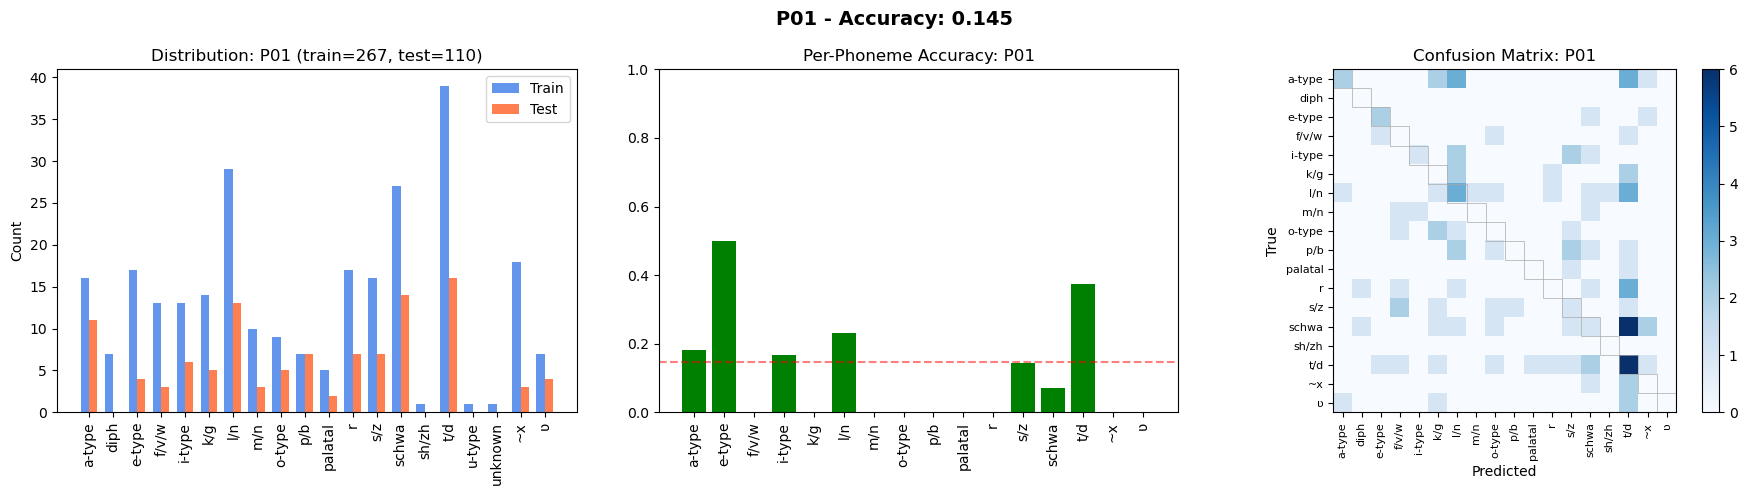


P01 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.18     11  t/d(3), l/n(3), k/g(2)
e-type    0.50      4  ~x(1), schwa(1)
f/v/w     0.00      3  o-type(1), t/d(1), e-type(1)
i-type    0.17      6  s/z(2), l/n(2), schwa(1)
k/g       0.00      5  l/n(2), t/d(2), r(1)
l/n       0.23     13  t/d(3), a-type(1), k/g(1)
m/n       0.00      3  f/v/w(1), schwa(1), i-type(1)
o-type    0.00      5  k/g(2), s/z(1), l/n(1)
p/b       0.00      7  s/z(2), l/n(2), schwa(1)
palatal   0.00      2  t/d(1), s/z(1)
r         0.00      7  t/d(3), schwa(1), diph(1)
s/z       0.14      7  f/v/w(2), t/d(1), k/g(1)
schwa     0.07     14  t/d(6), ~x(2), k/g(1)
t/d       0.38     16  schwa(2), k/g(1), palatal(1)
~x        0.00      3  t/d(2), schwa(1)
ʋ         0.00      4  t/d(2), a-type(1), k/g(1)



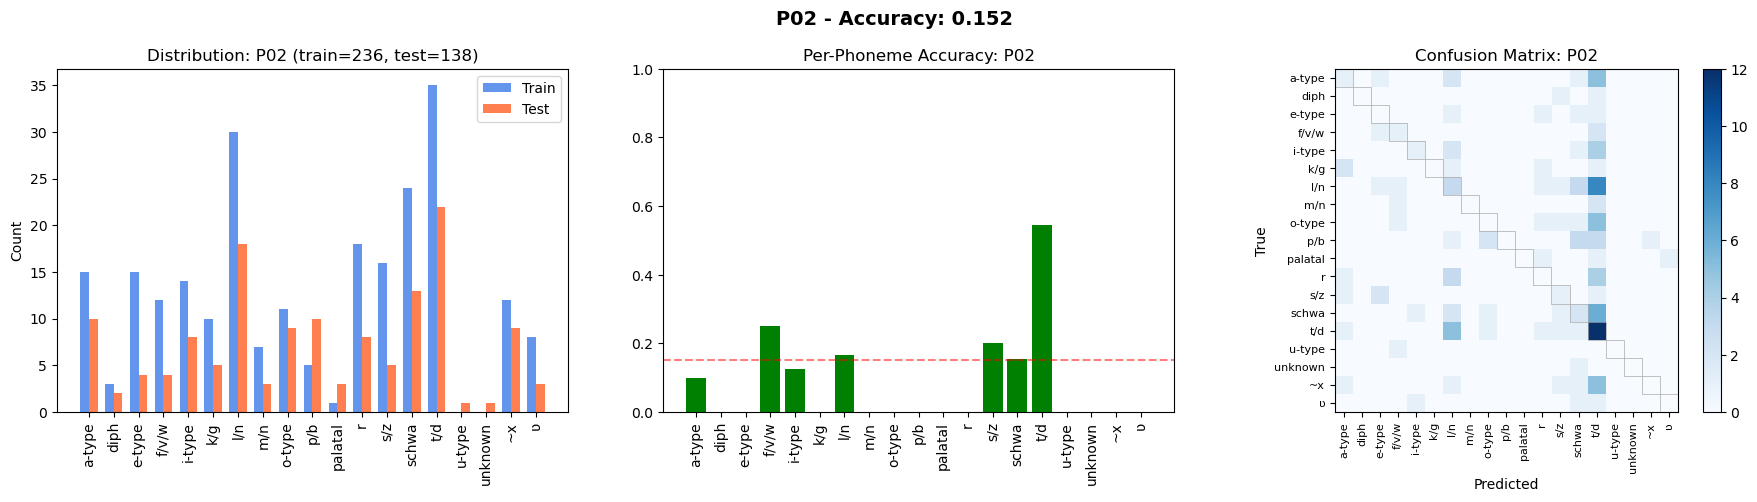


P02 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.10     10  t/d(5), l/n(2), schwa(1)
diph      0.00      2  s/z(1), t/d(1)
e-type    0.00      4  schwa(1), l/n(1), t/d(1)
f/v/w     0.25      4  t/d(2), e-type(1)
i-type    0.12      8  t/d(4), l/n(2), schwa(1)
k/g       0.00      5  a-type(2), r(1), t/d(1)
l/n       0.17     18  t/d(8), schwa(3), f/v/w(1)
m/n       0.00      3  t/d(2), f/v/w(1)
o-type    0.00      9  t/d(5), s/z(1), f/v/w(1)
p/b       0.00     10  schwa(3), t/d(3), o-type(2)
palatal   0.00      3  ʋ(1), r(1), t/d(1)
r         0.00      8  t/d(4), l/n(3), a-type(1)
s/z       0.20      5  e-type(2), a-type(1), t/d(1)
schwa     0.15     13  t/d(6), l/n(2), o-type(1)
t/d       0.55     22  l/n(5), o-type(1), r(1)
u-type    0.00      1  f/v/w(1)
unknown   0.00      1  schwa(1)
~x        0.00      9  t/d(5), s/z(1), a-type(1)
ʋ         0.00      3  i-type(1), schwa(1), t/d(1)

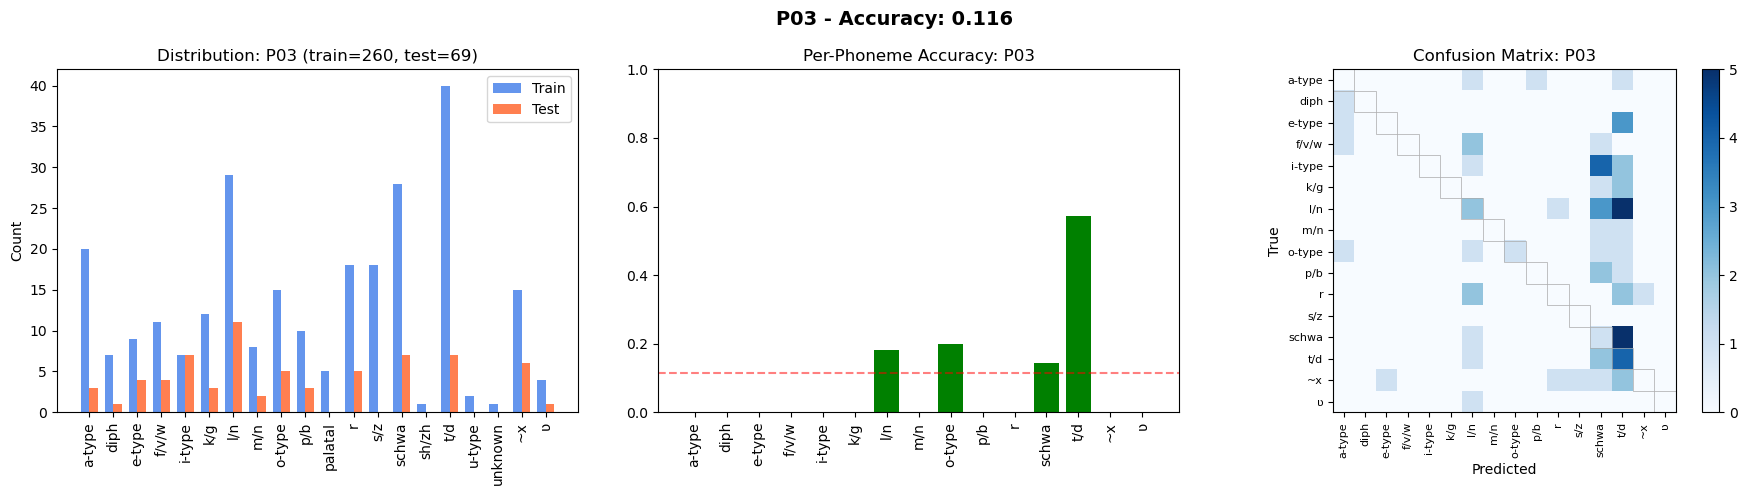


P03 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      3  t/d(1), l/n(1), p/b(1)
diph      0.00      1  a-type(1)
e-type    0.00      4  t/d(3), a-type(1)
f/v/w     0.00      4  l/n(2), schwa(1), a-type(1)
i-type    0.00      7  schwa(4), t/d(2), l/n(1)
k/g       0.00      3  t/d(2), schwa(1)
l/n       0.18     11  t/d(5), schwa(3), r(1)
m/n       0.00      2  t/d(1), schwa(1)
o-type    0.20      5  a-type(1), t/d(1), l/n(1)
p/b       0.00      3  schwa(2), t/d(1)
r         0.00      5  t/d(2), l/n(2), ~x(1)
schwa     0.14      7  t/d(5), l/n(1)
t/d       0.57      7  schwa(2), l/n(1)
~x        0.00      6  t/d(2), r(1), schwa(1)
ʋ         0.00      1  l/n(1)



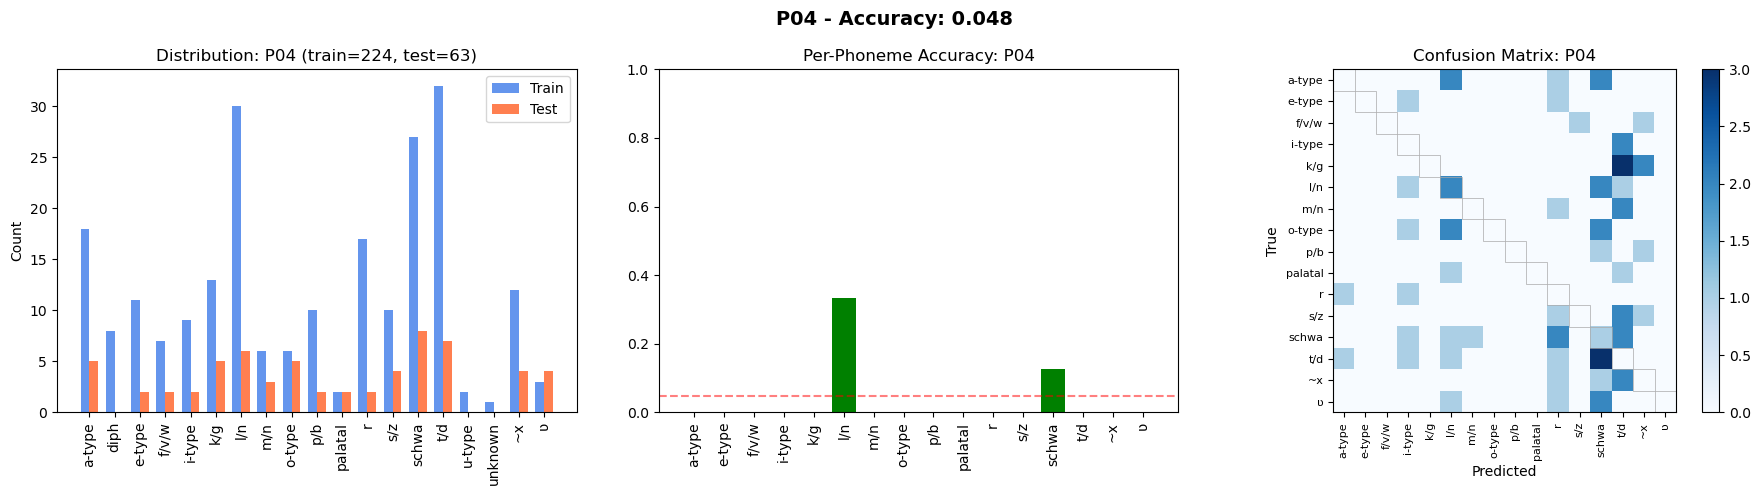


P04 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      5  l/n(2), schwa(2), r(1)
e-type    0.00      2  r(1), i-type(1)
f/v/w     0.00      2  s/z(1), ~x(1)
i-type    0.00      2  t/d(2)
k/g       0.00      5  t/d(3), ~x(2)
l/n       0.33      6  schwa(2), t/d(1), i-type(1)
m/n       0.00      3  t/d(2), r(1)
o-type    0.00      5  l/n(2), schwa(2), i-type(1)
p/b       0.00      2  ~x(1), schwa(1)
palatal   0.00      2  l/n(1), t/d(1)
r         0.00      2  i-type(1), a-type(1)
s/z       0.00      4  t/d(2), r(1), ~x(1)
schwa     0.12      8  t/d(2), r(2), m/n(1)
t/d       0.00      7  schwa(3), a-type(1), r(1)
~x        0.00      4  t/d(2), r(1), schwa(1)
ʋ         0.00      4  schwa(2), l/n(1), r(1)



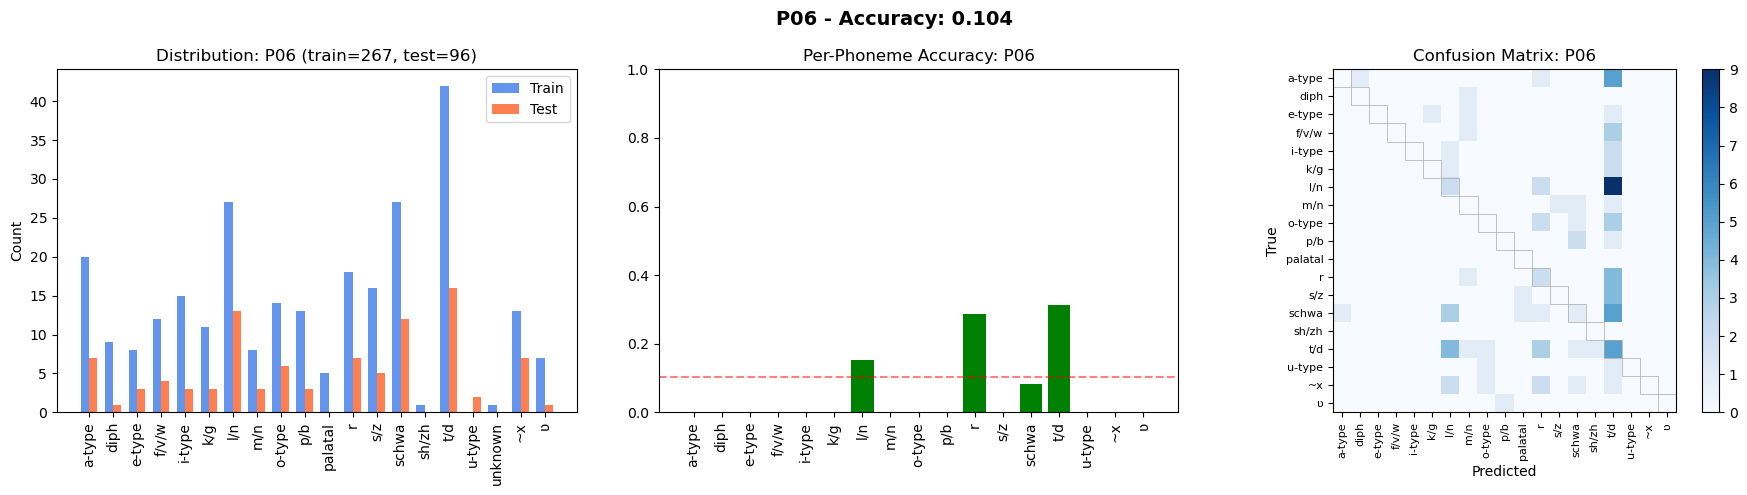


P06 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      7  t/d(5), diph(1), r(1)
diph      0.00      1  m/n(1)
e-type    0.00      3  t/d(1), k/g(1), m/n(1)
f/v/w     0.00      4  t/d(3), m/n(1)
i-type    0.00      3  t/d(2), l/n(1)
k/g       0.00      3  t/d(2), l/n(1)
l/n       0.15     13  t/d(9), r(2)
m/n       0.00      3  s/z(1), t/d(1), schwa(1)
o-type    0.00      6  t/d(3), r(2), schwa(1)
p/b       0.00      3  schwa(2), t/d(1)
r         0.29      7  t/d(4), m/n(1)
s/z       0.00      5  t/d(4), palatal(1)
schwa     0.08     12  t/d(5), l/n(3), palatal(1)
t/d       0.31     16  l/n(4), r(3), schwa(1)
u-type    0.00      2  o-type(1), t/d(1)
~x        0.00      7  r(2), l/n(2), o-type(1)
ʋ         0.00      1  p/b(1)



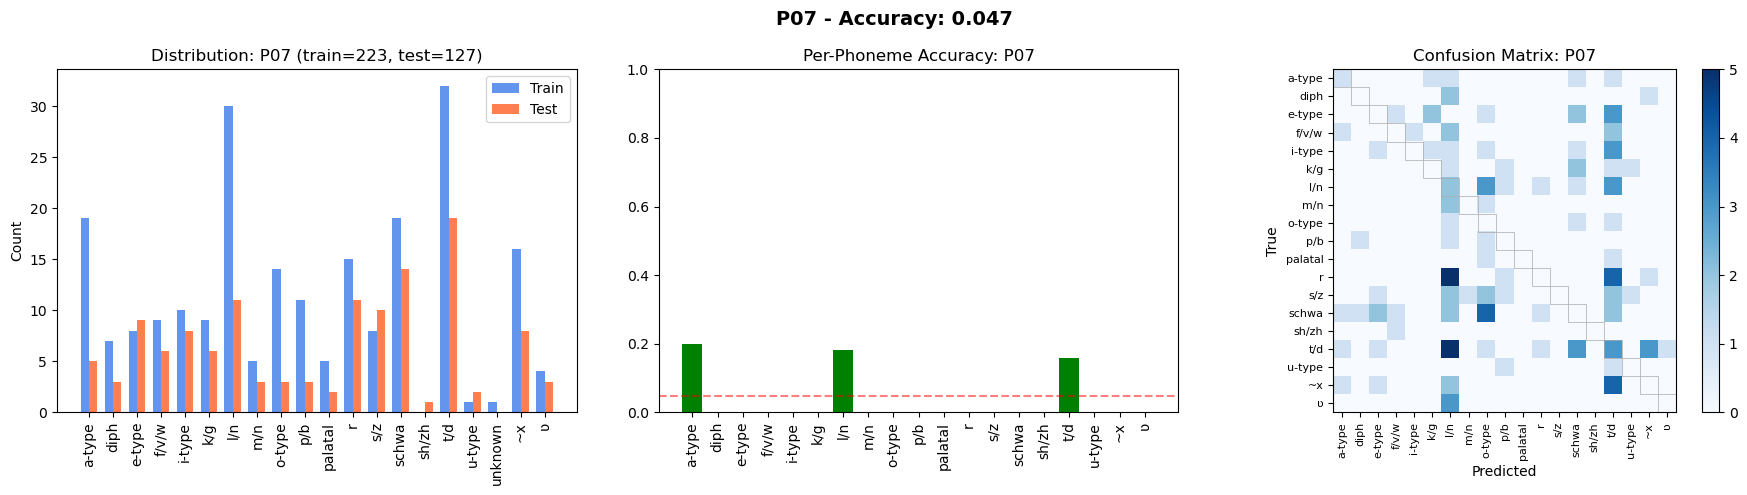


P07 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.20      5  t/d(1), l/n(1), schwa(1)
diph      0.00      3  l/n(2), ~x(1)
e-type    0.00      9  t/d(3), k/g(2), schwa(2)
f/v/w     0.00      6  l/n(2), t/d(2), i-type(1)
i-type    0.00      8  t/d(3), o-type(1), e-type(1)
k/g       0.00      6  schwa(2), t/d(1), p/b(1)
l/n       0.18     11  o-type(3), t/d(3), schwa(1)
m/n       0.00      3  l/n(2), o-type(1)
o-type    0.00      3  l/n(1), t/d(1), schwa(1)
p/b       0.00      3  o-type(1), diph(1), l/n(1)
palatal   0.00      2  o-type(1), t/d(1)
r         0.00     11  l/n(5), t/d(4), p/b(1)
s/z       0.00     10  o-type(2), l/n(2), t/d(2)
schwa     0.00     14  o-type(4), t/d(2), e-type(2)
sh/zh     0.00      1  f/v/w(1)
t/d       0.16     19  l/n(5), schwa(3), ~x(3)
u-type    0.00      2  t/d(1), p/b(1)
~x        0.00      8  t/d(4), l/n(2), a-type(1)
ʋ         0.00      3  l/n(3)



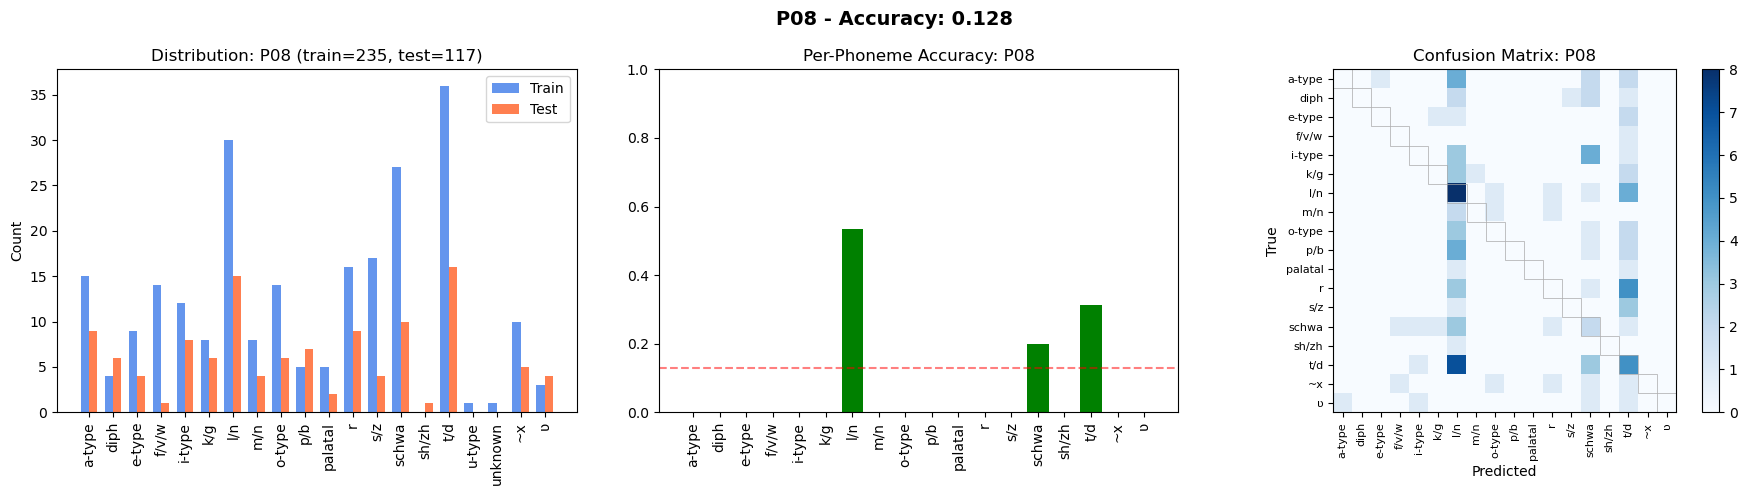


P08 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      9  l/n(4), t/d(2), schwa(2)
diph      0.00      6  schwa(2), l/n(2), s/z(1)
e-type    0.00      4  t/d(2), k/g(1), l/n(1)
f/v/w     0.00      1  t/d(1)
i-type    0.00      8  schwa(4), l/n(3), t/d(1)
k/g       0.00      6  l/n(3), t/d(2), m/n(1)
l/n       0.53     15  t/d(4), schwa(1), o-type(1)
m/n       0.00      4  l/n(2), o-type(1), r(1)
o-type    0.00      6  l/n(3), t/d(2), schwa(1)
p/b       0.00      7  l/n(4), t/d(2), schwa(1)
palatal   0.00      2  t/d(1), l/n(1)
r         0.00      9  t/d(5), l/n(3), schwa(1)
s/z       0.00      4  t/d(3), l/n(1)
schwa     0.20     10  l/n(3), r(1), i-type(1)
sh/zh     0.00      1  l/n(1)
t/d       0.31     16  l/n(7), schwa(3), i-type(1)
~x        0.00      5  o-type(1), r(1), schwa(1)
ʋ         0.00      4  a-type(1), t/d(1), schwa(1)



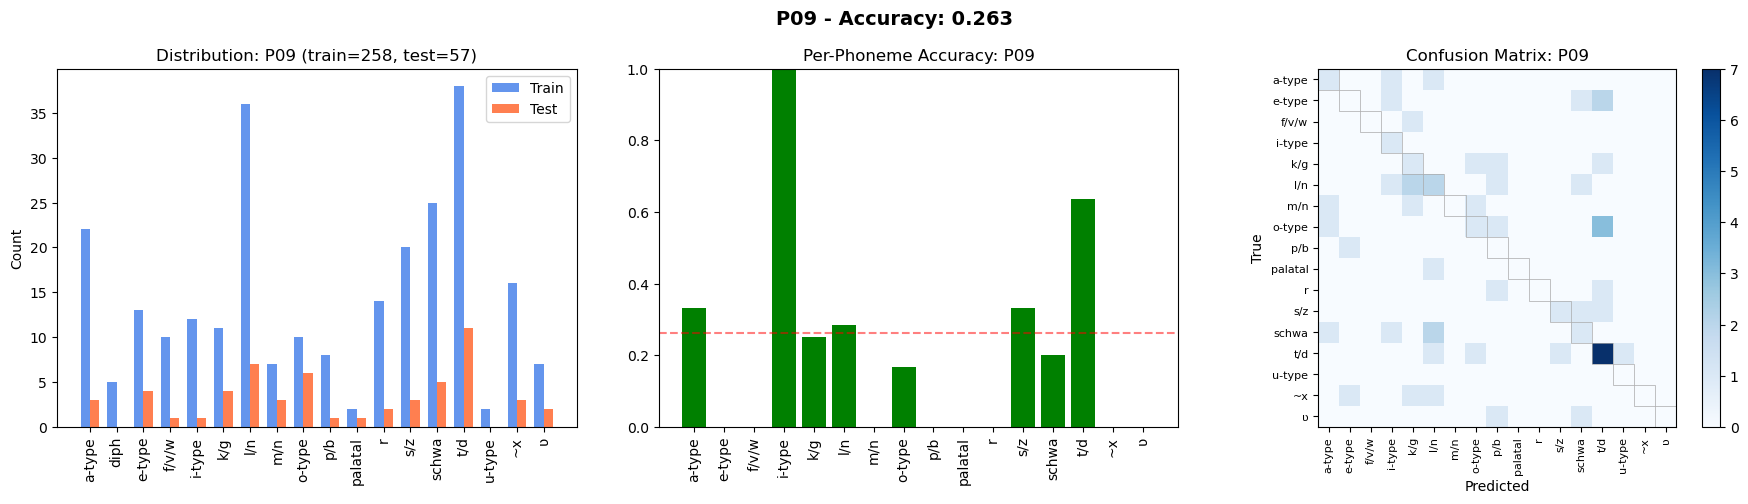


P09 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.33      3  i-type(1), l/n(1)
e-type    0.00      4  t/d(2), schwa(1), i-type(1)
f/v/w     0.00      1  k/g(1)
i-type    1.00      1  -
k/g       0.25      4  t/d(1), o-type(1), p/b(1)
l/n       0.29      7  k/g(2), i-type(1), schwa(1)
m/n       0.00      3  k/g(1), a-type(1), o-type(1)
o-type    0.17      6  t/d(3), p/b(1), a-type(1)
p/b       0.00      1  e-type(1)
palatal   0.00      1  l/n(1)
r         0.00      2  p/b(1), t/d(1)
s/z       0.33      3  t/d(1), schwa(1)
schwa     0.20      5  l/n(2), a-type(1), i-type(1)
t/d       0.64     11  o-type(1), l/n(1), u-type(1)
~x        0.00      3  k/g(1), e-type(1), l/n(1)
ʋ         0.00      2  schwa(1), p/b(1)



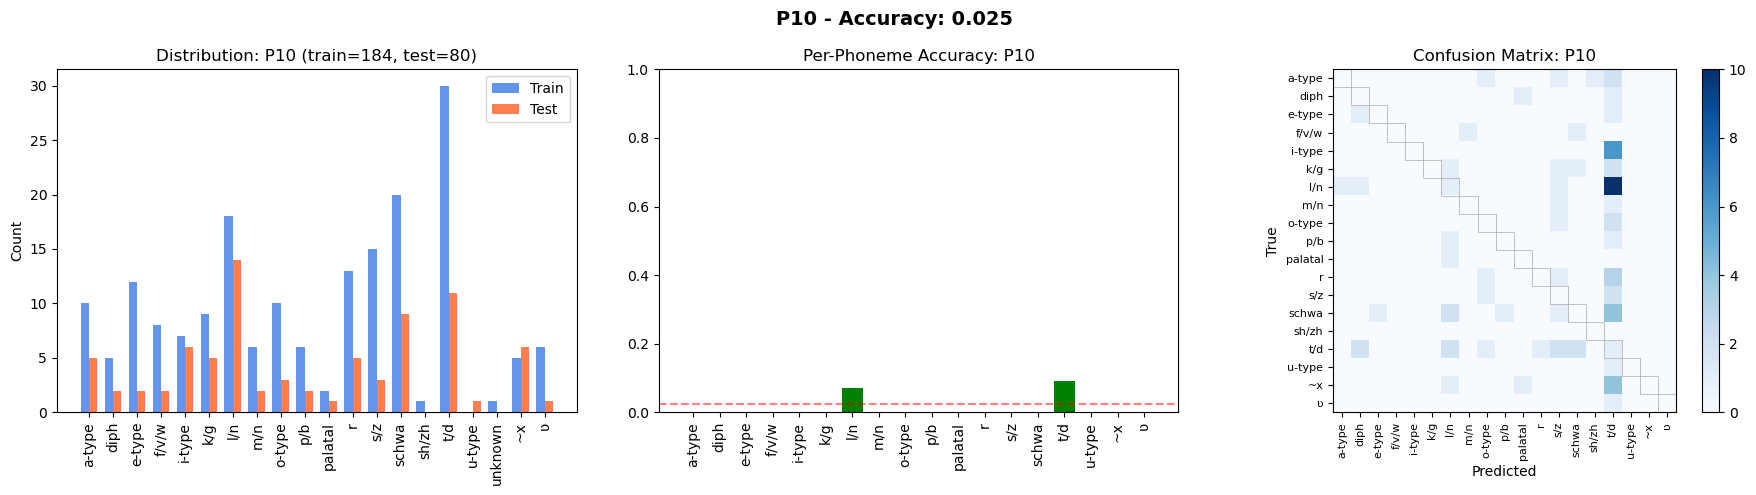


P10 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      5  t/d(2), s/z(1), o-type(1)
diph      0.00      2  t/d(1), palatal(1)
e-type    0.00      2  diph(1), t/d(1)
f/v/w     0.00      2  schwa(1), m/n(1)
i-type    0.00      6  t/d(6)
k/g       0.00      5  t/d(2), l/n(1), s/z(1)
l/n       0.07     14  t/d(10), s/z(1), diph(1)
m/n       0.00      2  t/d(1), s/z(1)
o-type    0.00      3  t/d(2), s/z(1)
p/b       0.00      2  t/d(1), l/n(1)
palatal   0.00      1  l/n(1)
r         0.00      5  t/d(3), s/z(1), o-type(1)
s/z       0.00      3  t/d(2), o-type(1)
schwa     0.00      9  t/d(4), l/n(2), p/b(1)
t/d       0.09     11  s/z(2), diph(2), schwa(2)
u-type    0.00      1  t/d(1)
~x        0.00      6  t/d(4), l/n(1), palatal(1)
ʋ         0.00      1  t/d(1)



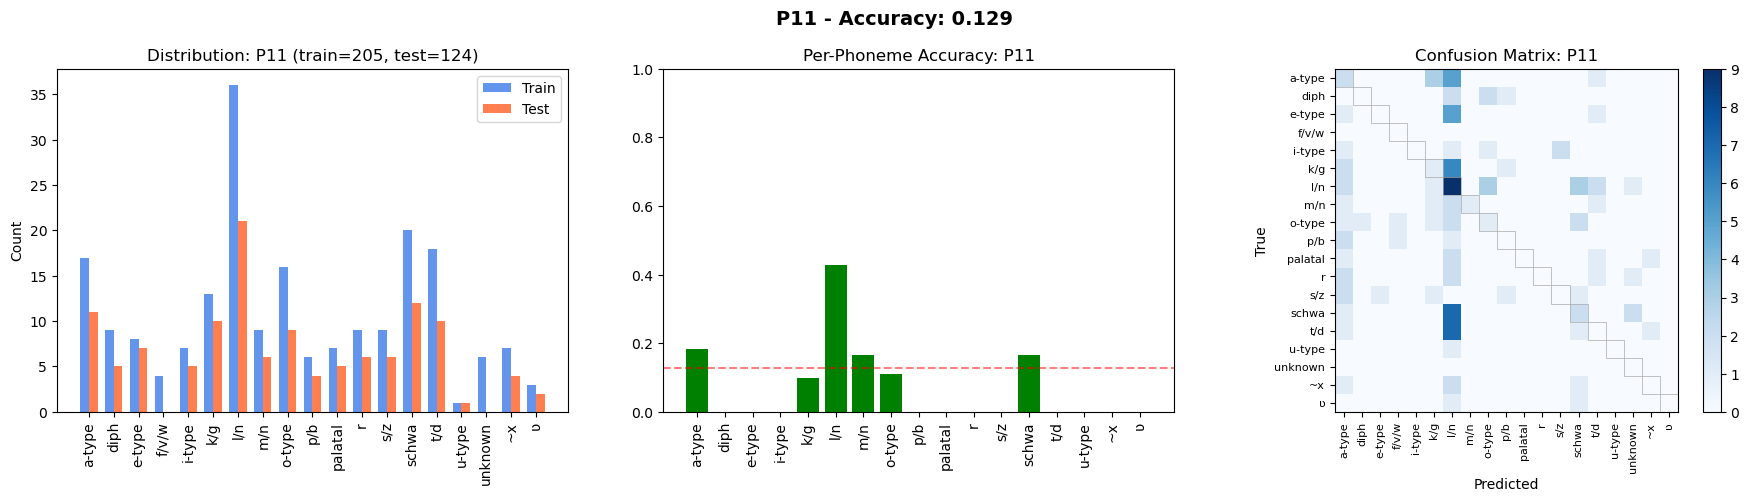


P11 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.18     11  l/n(5), k/g(3), t/d(1)
diph      0.00      5  l/n(2), o-type(2), p/b(1)
e-type    0.00      7  l/n(5), t/d(1), a-type(1)
i-type    0.00      5  s/z(2), l/n(1), o-type(1)
k/g       0.10     10  l/n(6), a-type(2), p/b(1)
l/n       0.43     21  schwa(3), o-type(3), t/d(2)
m/n       0.17      6  l/n(2), a-type(1), t/d(1)
o-type    0.11      9  schwa(2), l/n(2), a-type(1)
p/b       0.00      4  a-type(2), f/v/w(1), l/n(1)
palatal   0.00      5  l/n(2), t/d(1), ~x(1)
r         0.00      6  a-type(2), l/n(2), t/d(1)
s/z       0.00      6  a-type(2), k/g(1), schwa(1)
schwa     0.17     12  l/n(7), unknown(2), a-type(1)
t/d       0.00     10  l/n(7), a-type(1), ~x(1)
u-type    0.00      1  l/n(1)
~x        0.00      4  l/n(2), a-type(1), schwa(1)
ʋ         0.00      2  l/n(1), schwa(1)



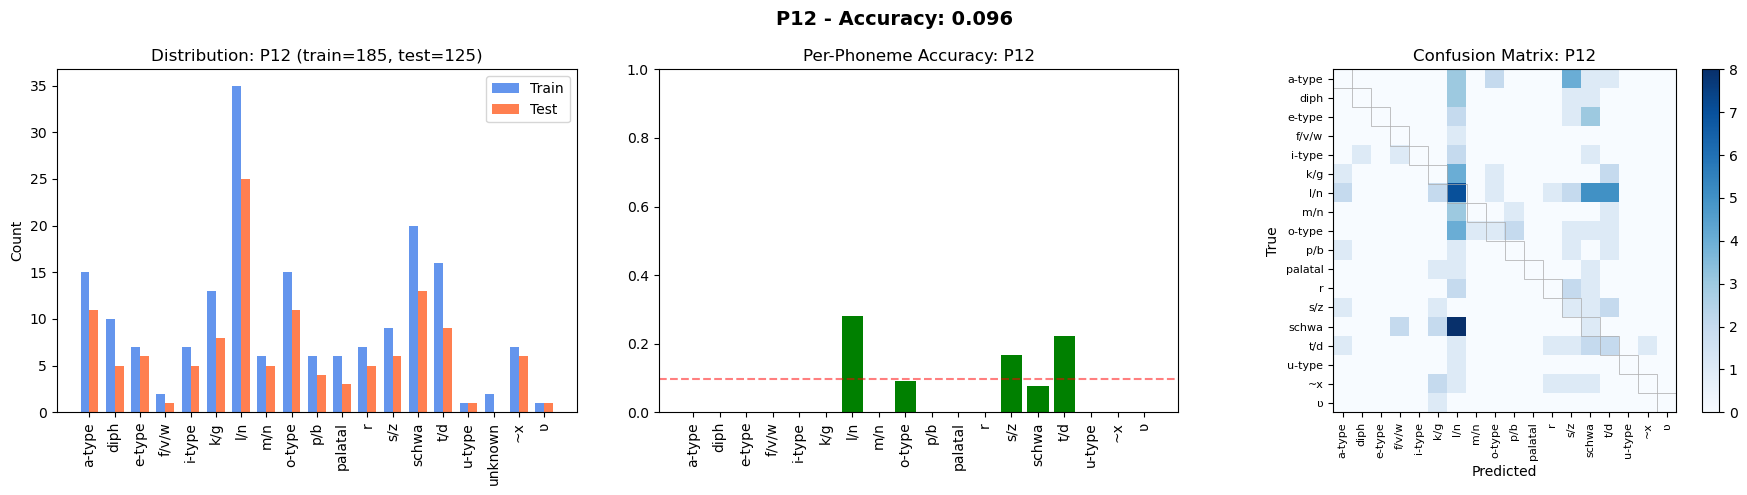


P12 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00     11  s/z(4), l/n(3), o-type(2)
diph      0.00      5  l/n(3), schwa(1), s/z(1)
e-type    0.00      6  schwa(3), l/n(2), s/z(1)
f/v/w     0.00      1  l/n(1)
i-type    0.00      5  l/n(2), diph(1), schwa(1)
k/g       0.00      8  l/n(4), t/d(2), o-type(1)
l/n       0.28     25  t/d(5), schwa(5), a-type(2)
m/n       0.00      5  l/n(3), t/d(1), p/b(1)
o-type    0.09     11  l/n(4), p/b(2), s/z(1)
p/b       0.00      4  s/z(1), t/d(1), l/n(1)
palatal   0.00      3  k/g(1), l/n(1), schwa(1)
r         0.00      5  l/n(2), s/z(2), schwa(1)
s/z       0.17      6  t/d(2), a-type(1), k/g(1)
schwa     0.08     13  l/n(8), k/g(2), f/v/w(2)
t/d       0.22      9  schwa(2), l/n(1), s/z(1)
u-type    0.00      1  l/n(1)
~x        0.00      6  k/g(2), schwa(1), s/z(1)
ʋ         0.00      1  k/g(1)



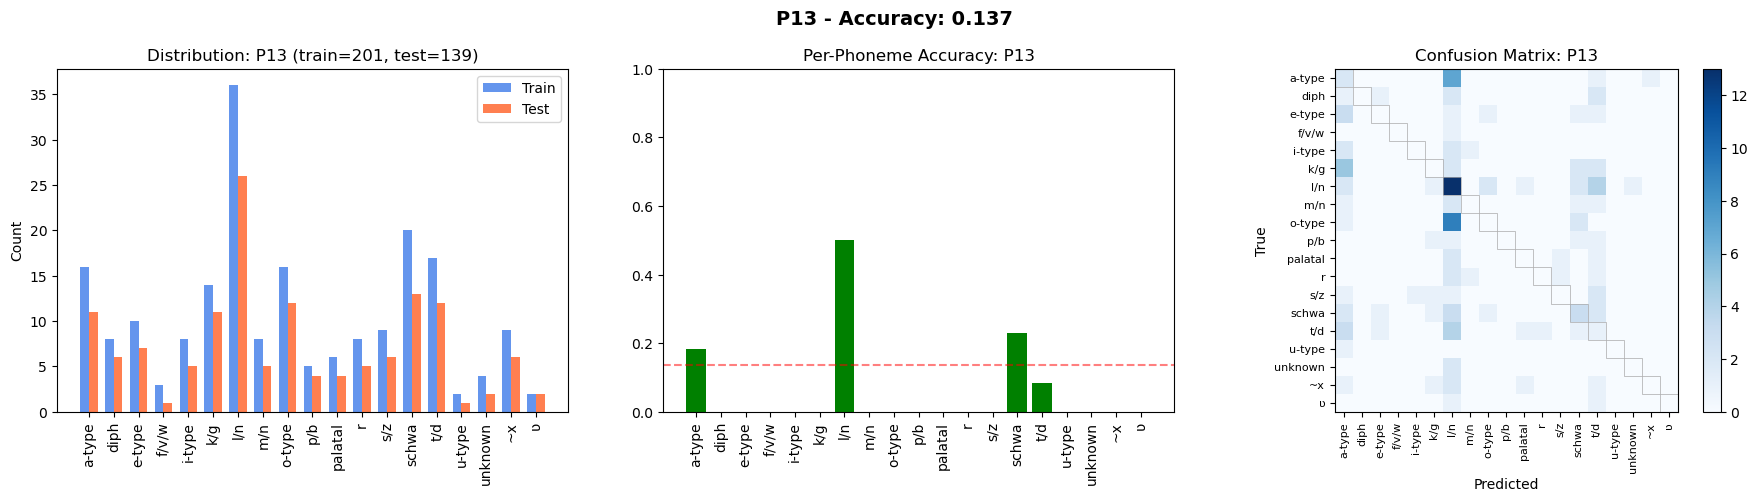


P13 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.18     11  l/n(7), t/d(1), ~x(1)
diph      0.00      6  l/n(2), t/d(2), e-type(1)
e-type    0.00      7  a-type(3), l/n(1), t/d(1)
f/v/w     0.00      1  l/n(1)
i-type    0.00      5  l/n(2), a-type(2), m/n(1)
k/g       0.00     11  a-type(5), l/n(2), t/d(2)
l/n       0.50     26  t/d(4), a-type(2), o-type(2)
m/n       0.00      5  l/n(2), t/d(1), schwa(1)
o-type    0.00     12  l/n(9), schwa(2), a-type(1)
p/b       0.00      4  k/g(1), t/d(1), schwa(1)
palatal   0.00      4  l/n(2), s/z(1), t/d(1)
r         0.00      5  l/n(2), m/n(1), s/z(1)
s/z       0.00      6  t/d(2), l/n(1), k/g(1)
schwa     0.23     13  l/n(3), t/d(2), a-type(2)
t/d       0.08     12  l/n(4), a-type(3), r(1)
u-type    0.00      1  a-type(1)
unknown   0.00      2  l/n(2)
~x        0.00      6  l/n(2), a-type(1), k/g(1)
ʋ         0.00      2  l/n(1), t/d(1)



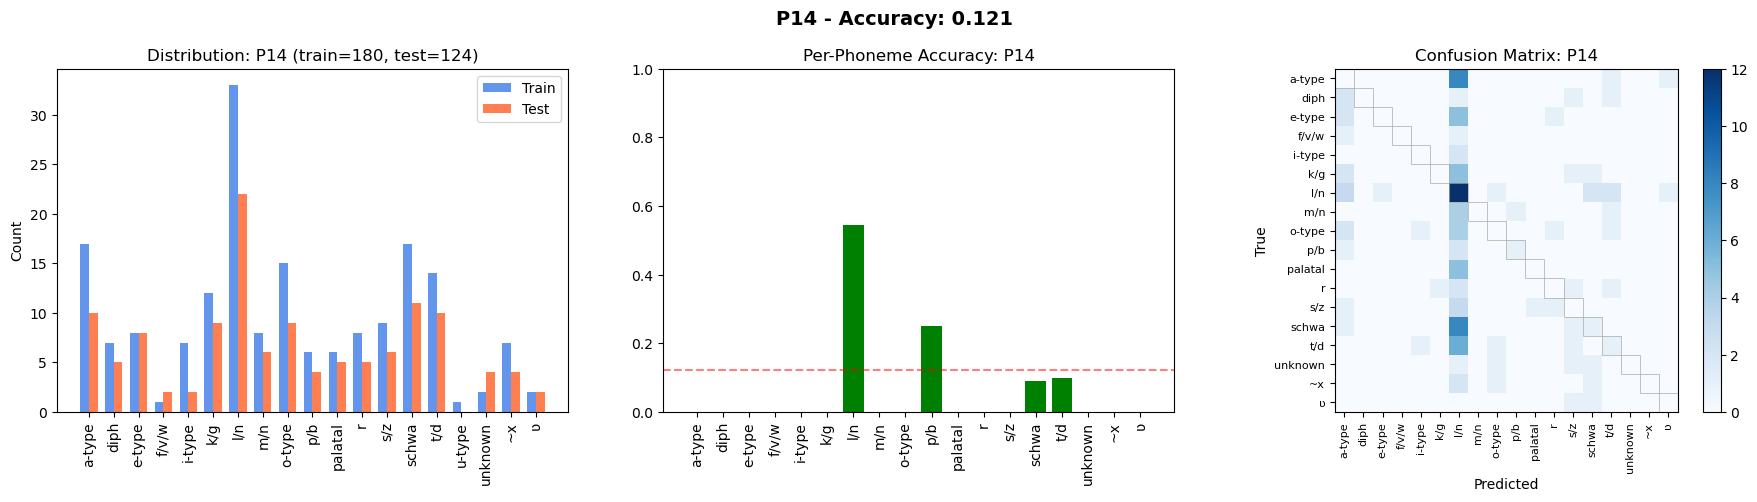


P14 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00     10  l/n(8), ʋ(1), t/d(1)
diph      0.00      5  a-type(2), s/z(1), t/d(1)
e-type    0.00      8  l/n(5), a-type(2), r(1)
f/v/w     0.00      2  a-type(1), l/n(1)
i-type    0.00      2  l/n(2)
k/g       0.00      9  l/n(5), a-type(2), s/z(1)
l/n       0.55     22  a-type(3), t/d(2), schwa(2)
m/n       0.00      6  l/n(4), p/b(1), t/d(1)
o-type    0.00      9  l/n(4), a-type(2), t/d(1)
p/b       0.25      4  l/n(2), a-type(1)
palatal   0.00      5  l/n(5)
r         0.00      5  l/n(2), k/g(1), t/d(1)
s/z       0.00      6  l/n(3), palatal(1), a-type(1)
schwa     0.09     11  l/n(8), a-type(1), s/z(1)
t/d       0.10     10  l/n(6), i-type(1), o-type(1)
unknown   0.00      4  l/n(1), o-type(1), s/z(1)
~x        0.00      4  l/n(2), schwa(1), o-type(1)
ʋ         0.00      2  s/z(1), schwa(1)



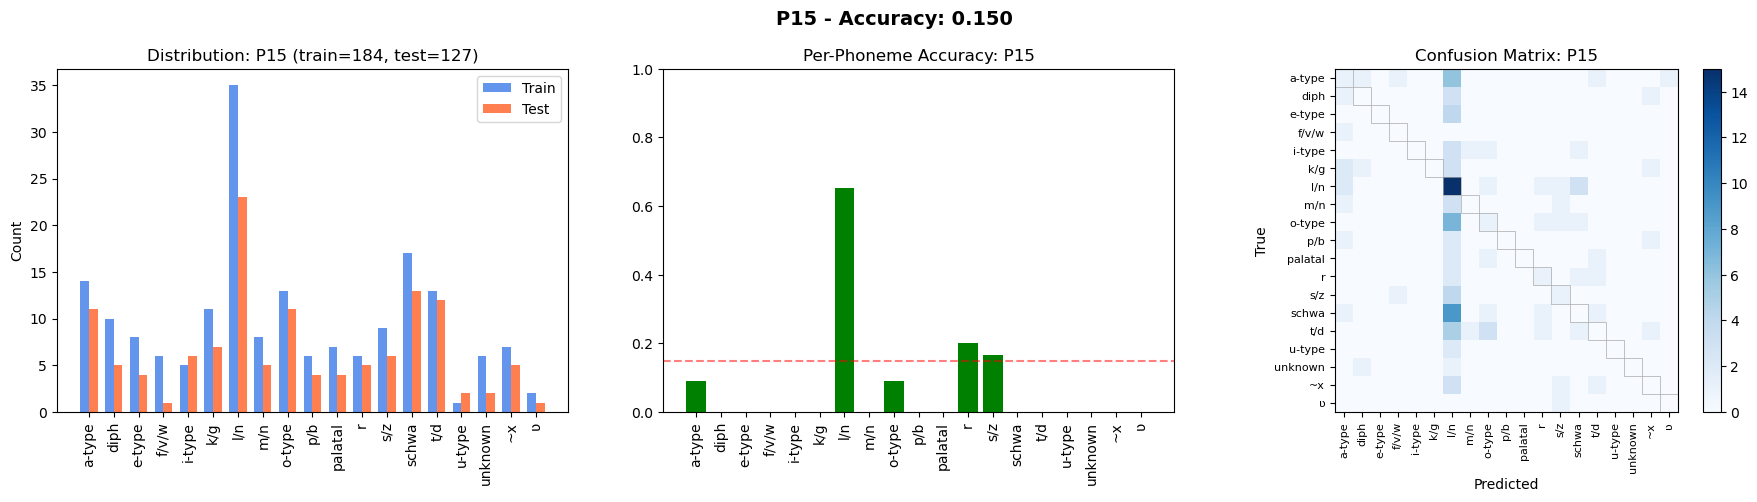


P15 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.09     11  l/n(6), diph(1), t/d(1)
diph      0.00      5  l/n(3), a-type(1), ~x(1)
e-type    0.00      4  l/n(4)
f/v/w     0.00      1  a-type(1)
i-type    0.00      6  l/n(3), o-type(1), schwa(1)
k/g       0.00      7  l/n(3), a-type(2), diph(1)
l/n       0.65     23  schwa(3), a-type(2), s/z(1)
m/n       0.00      5  l/n(3), s/z(1), a-type(1)
o-type    0.09     11  l/n(7), schwa(1), r(1)
p/b       0.00      4  l/n(2), a-type(1), ~x(1)
palatal   0.00      4  l/n(2), t/d(1), o-type(1)
r         0.20      5  l/n(2), t/d(1), schwa(1)
s/z       0.17      6  l/n(4), f/v/w(1)
schwa     0.00     13  l/n(9), r(1), t/d(1)
t/d       0.00     12  l/n(5), o-type(3), m/n(1)
u-type    0.00      2  l/n(2)
unknown   0.00      2  diph(1), l/n(1)
~x        0.00      5  l/n(3), t/d(1), s/z(1)
ʋ         0.00      1  s/z(1)



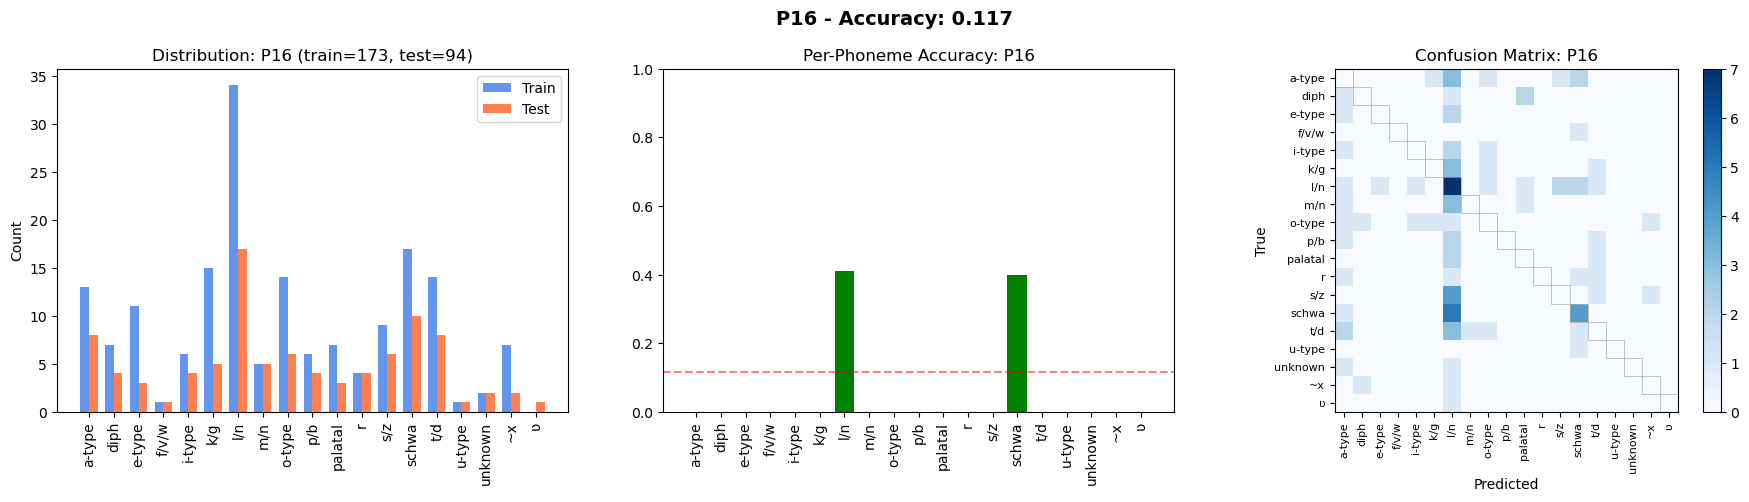


P16 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      8  l/n(3), schwa(2), s/z(1)
diph      0.00      4  palatal(2), l/n(1), a-type(1)
e-type    0.00      3  l/n(2), a-type(1)
f/v/w     0.00      1  schwa(1)
i-type    0.00      4  l/n(2), o-type(1), a-type(1)
k/g       0.00      5  l/n(3), o-type(1), t/d(1)
l/n       0.41     17  s/z(2), schwa(2), i-type(1)
m/n       0.00      5  l/n(3), a-type(1), palatal(1)
o-type    0.00      6  k/g(1), ~x(1), a-type(1)
p/b       0.00      4  l/n(2), t/d(1), a-type(1)
palatal   0.00      3  l/n(2), t/d(1)
r         0.00      4  a-type(1), t/d(1), l/n(1)
s/z       0.00      6  l/n(4), ~x(1), t/d(1)
schwa     0.40     10  l/n(5), a-type(1)
t/d       0.00      8  l/n(3), a-type(2), schwa(1)
u-type    0.00      1  schwa(1)
unknown   0.00      2  a-type(1), l/n(1)
~x        0.00      2  l/n(1), diph(1)
ʋ         0.00      1  l/n(1)



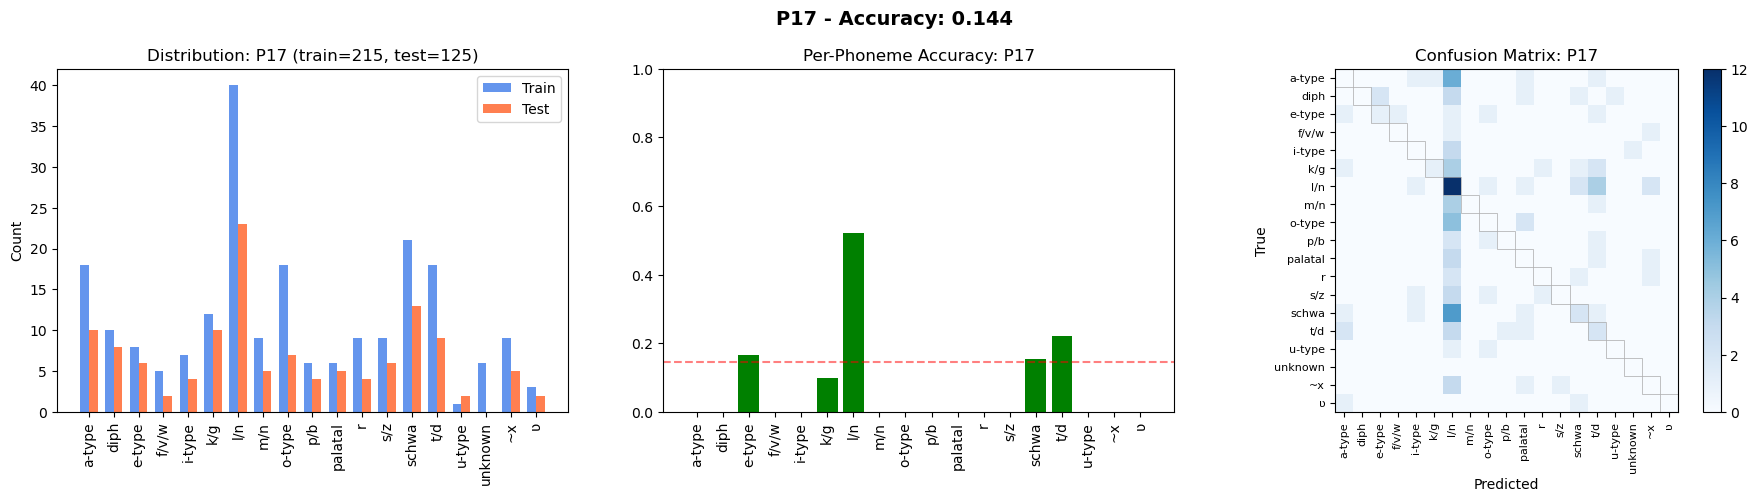


P17 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00     10  l/n(6), palatal(1), k/g(1)
diph      0.00      8  l/n(3), e-type(2), schwa(1)
e-type    0.17      6  a-type(1), l/n(1), t/d(1)
f/v/w     0.00      2  l/n(1), ~x(1)
i-type    0.00      4  l/n(3), unknown(1)
k/g       0.10     10  l/n(4), t/d(2), schwa(1)
l/n       0.52     23  t/d(4), ~x(2), schwa(2)
m/n       0.00      5  l/n(4), t/d(1)
o-type    0.00      7  l/n(5), palatal(2)
p/b       0.00      4  l/n(2), t/d(1), o-type(1)
palatal   0.00      5  l/n(3), ~x(1), t/d(1)
r         0.00      4  l/n(2), schwa(1), ~x(1)
s/z       0.00      6  l/n(3), i-type(1), r(1)
schwa     0.15     13  l/n(7), palatal(1), i-type(1)
t/d       0.22      9  l/n(3), a-type(2), p/b(1)
u-type    0.00      2  o-type(1), l/n(1)
~x        0.00      5  l/n(3), s/z(1), palatal(1)
ʋ         0.00      2  a-type(1), schwa(1)



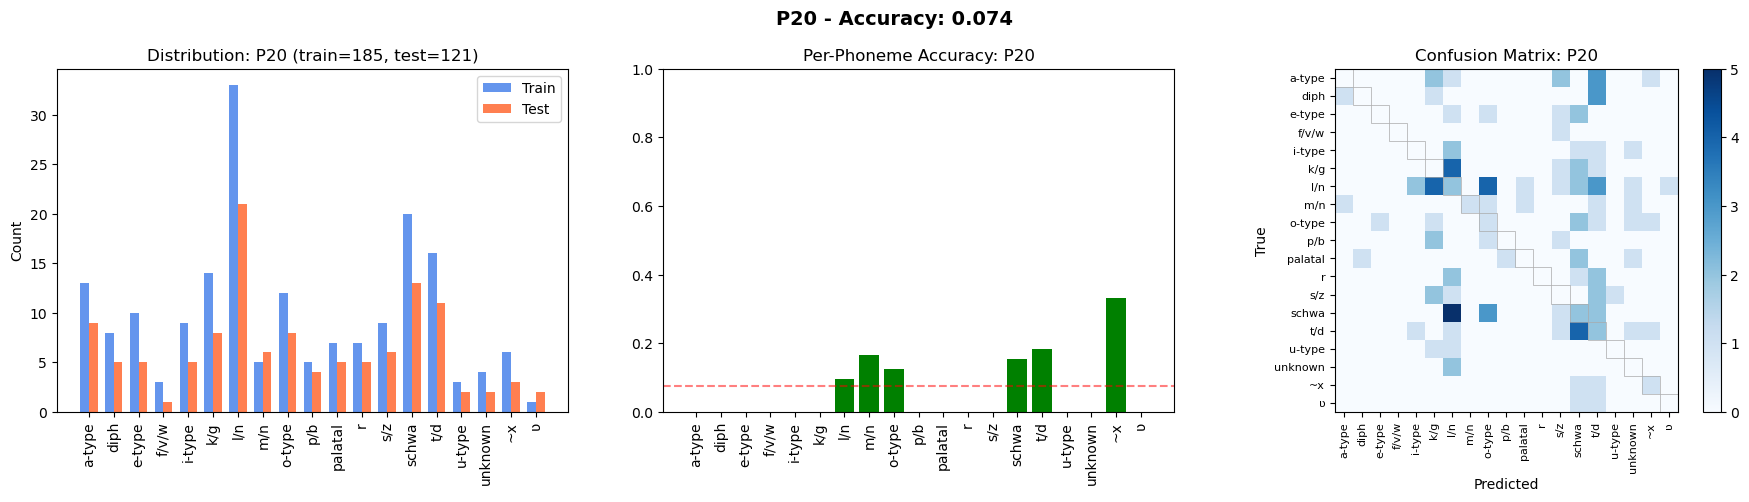


P20 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.00      9  t/d(3), k/g(2), s/z(2)
diph      0.00      5  t/d(3), a-type(1), k/g(1)
e-type    0.00      5  schwa(2), s/z(1), o-type(1)
f/v/w     0.00      1  s/z(1)
i-type    0.00      5  l/n(2), t/d(1), unknown(1)
k/g       0.00      8  l/n(4), schwa(2), s/z(1)
l/n       0.10     21  o-type(4), k/g(4), t/d(3)
m/n       0.17      6  o-type(1), t/d(1), a-type(1)
o-type    0.12      8  schwa(2), k/g(1), t/d(1)
p/b       0.00      4  k/g(2), s/z(1), o-type(1)
palatal   0.00      5  schwa(2), unknown(1), diph(1)
r         0.00      5  l/n(2), t/d(2), schwa(1)
s/z       0.00      6  t/d(2), k/g(2), l/n(1)
schwa     0.15     13  l/n(5), o-type(3), t/d(2)
t/d       0.18     11  schwa(4), l/n(1), unknown(1)
u-type    0.00      2  l/n(1), k/g(1)
unknown   0.00      2  l/n(2)
~x        0.33      3  t/d(1), schwa(1)
ʋ         0.00      2  schwa(1), 

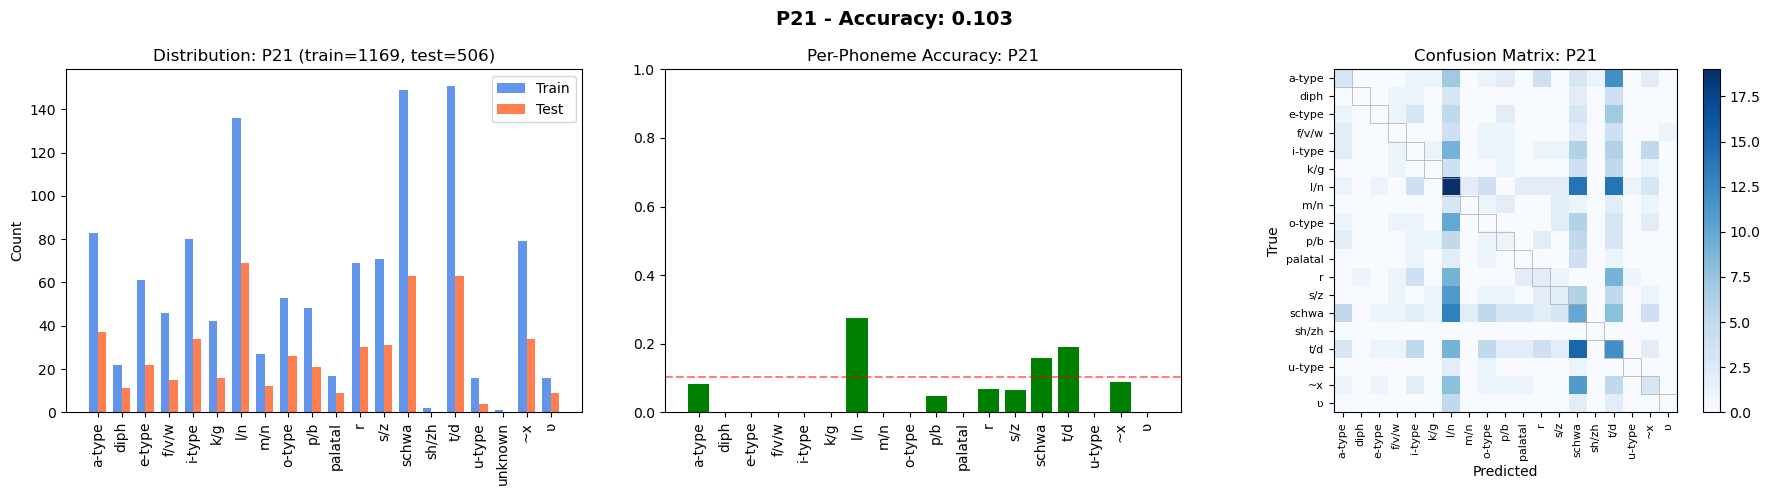


P21 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.08     37  t/d(12), l/n(7), r(4)
diph      0.00     11  t/d(4), l/n(3), schwa(2)
e-type    0.00     22  t/d(7), l/n(5), i-type(3)
f/v/w     0.00     15  l/n(4), t/d(4), a-type(2)
i-type    0.00     34  l/n(9), schwa(6), t/d(6)
k/g       0.00     16  t/d(5), schwa(4), l/n(4)
l/n       0.28     69  schwa(14), t/d(14), o-type(4)
m/n       0.00     12  l/n(3), p/b(2), s/z(2)
o-type    0.00     26  l/n(10), schwa(6), t/d(3)
p/b       0.05     21  schwa(5), l/n(5), t/d(3)
palatal   0.00      9  schwa(4), l/n(2), t/d(1)
r         0.07     30  t/d(9), l/n(9), i-type(4)
s/z       0.06     31  l/n(11), schwa(6), t/d(5)
schwa     0.16     63  l/n(13), t/d(8), a-type(5)
t/d       0.19     63  schwa(15), l/n(9), o-type(5)
u-type    0.00      4  l/n(2), schwa(1), o-type(1)
~x        0.09     34  schwa(11), l/n(8), t/d(5)
ʋ         0.00      9  l/n(5),

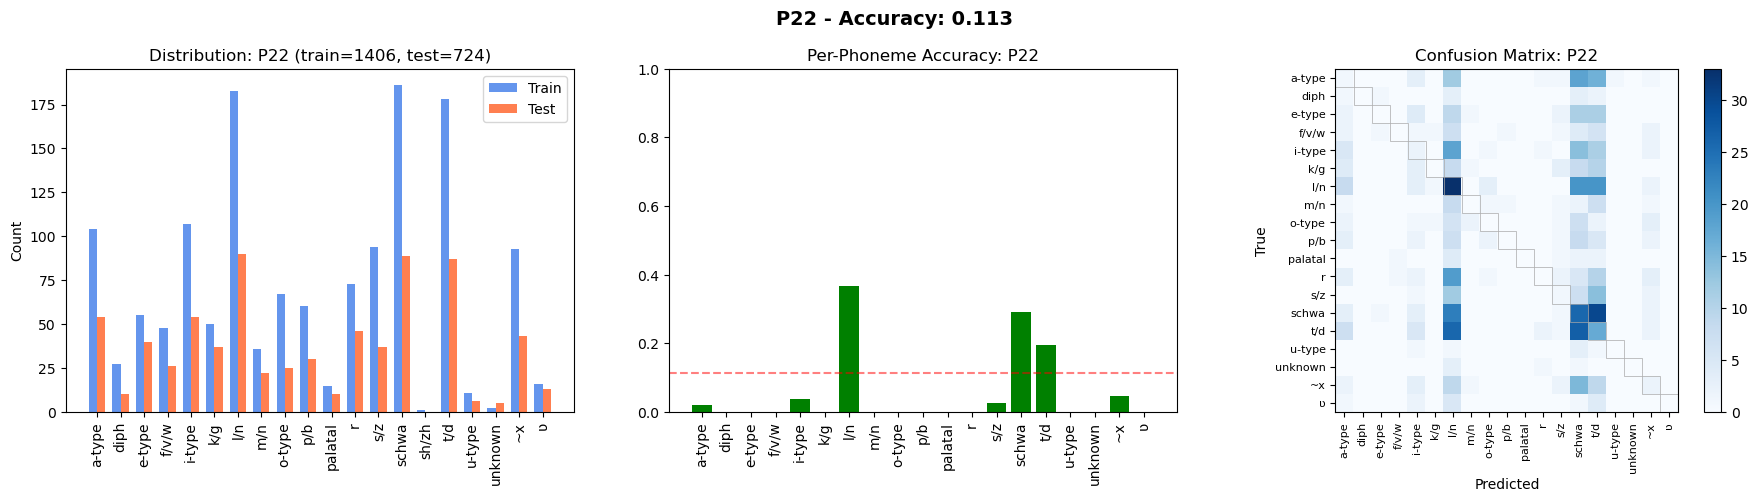


P22 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.02     54  schwa(18), t/d(16), l/n(12)
diph      0.00     10  schwa(3), l/n(3), t/d(2)
e-type    0.00     40  t/d(11), schwa(11), l/n(9)
f/v/w     0.00     26  l/n(7), t/d(6), schwa(4)
i-type    0.04     54  l/n(18), schwa(14), t/d(11)
k/g       0.00     37  t/d(10), schwa(8), l/n(8)
l/n       0.37     90  t/d(20), schwa(20), a-type(8)
m/n       0.00     22  l/n(8), t/d(7), schwa(2)
o-type    0.00     25  schwa(7), l/n(6), ~x(3)
p/b       0.00     30  schwa(8), l/n(7), t/d(5)
palatal   0.00     10  l/n(4), schwa(2), t/d(2)
r         0.00     46  l/n(19), t/d(10), schwa(5)
s/z       0.03     37  t/d(14), l/n(12), schwa(7)
schwa     0.29     89  t/d(30), l/n(23), i-type(3)
t/d       0.20     87  schwa(27), l/n(26), a-type(7)
u-type    0.00      6  schwa(3), t/d(1), l/n(1)
unknown   0.00      5  l/n(3), schwa(1), r(1)
~x        0.05     43 

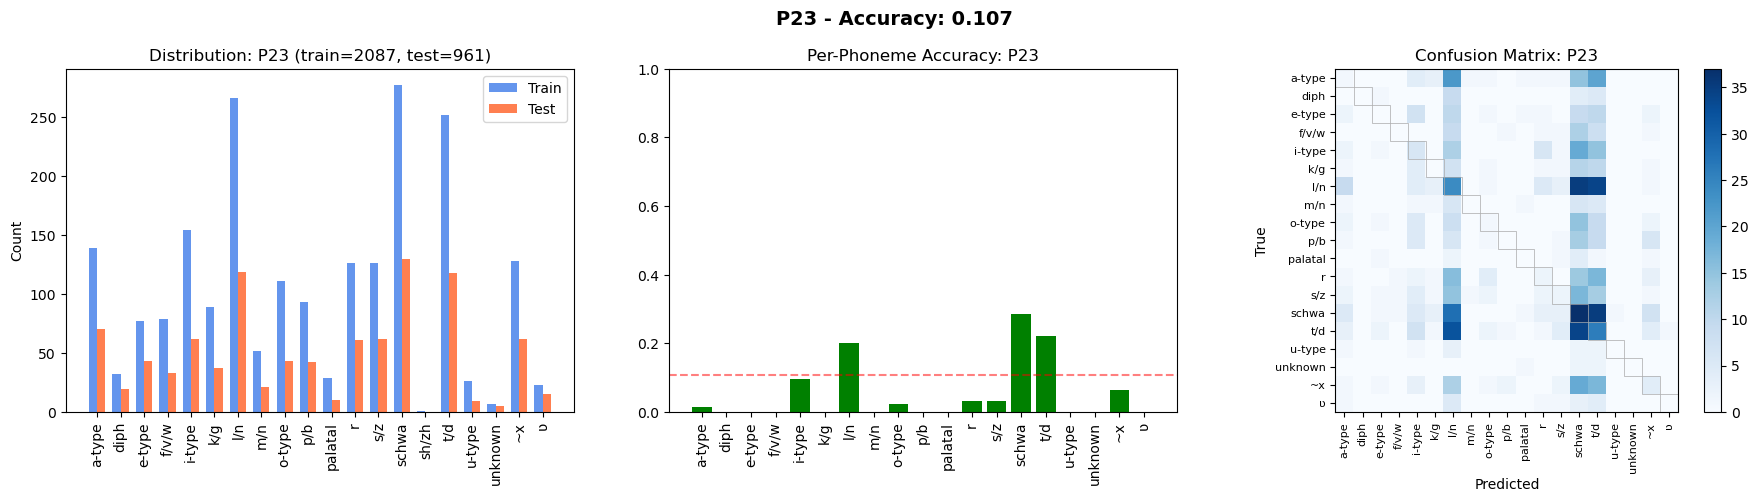


P23 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.01     70  l/n(22), t/d(20), schwa(15)
diph      0.00     19  l/n(9), t/d(5), schwa(4)
e-type    0.00     43  t/d(10), l/n(10), schwa(9)
f/v/w     0.00     33  schwa(12), l/n(9), t/d(8)
i-type    0.10     62  schwa(19), t/d(15), l/n(12)
k/g       0.00     37  schwa(11), t/d(10), l/n(7)
l/n       0.20    119  schwa(35), t/d(34), a-type(9)
m/n       0.00     21  l/n(6), schwa(6), t/d(5)
o-type    0.02     43  schwa(15), t/d(9), l/n(8)
p/b       0.00     42  schwa(13), t/d(9), ~x(6)
palatal   0.00     10  schwa(4), l/n(2), s/z(1)
r         0.03     61  t/d(17), l/n(16), schwa(14)
s/z       0.03     62  schwa(17), l/n(15), t/d(13)
schwa     0.28    130  t/d(35), l/n(28), ~x(7)
t/d       0.22    118  schwa(34), l/n(32), i-type(7)
u-type    0.00      9  l/n(3), t/d(2), schwa(2)
unknown   0.00      5  t/d(2), schwa(2), palatal(1)
~x        0.06

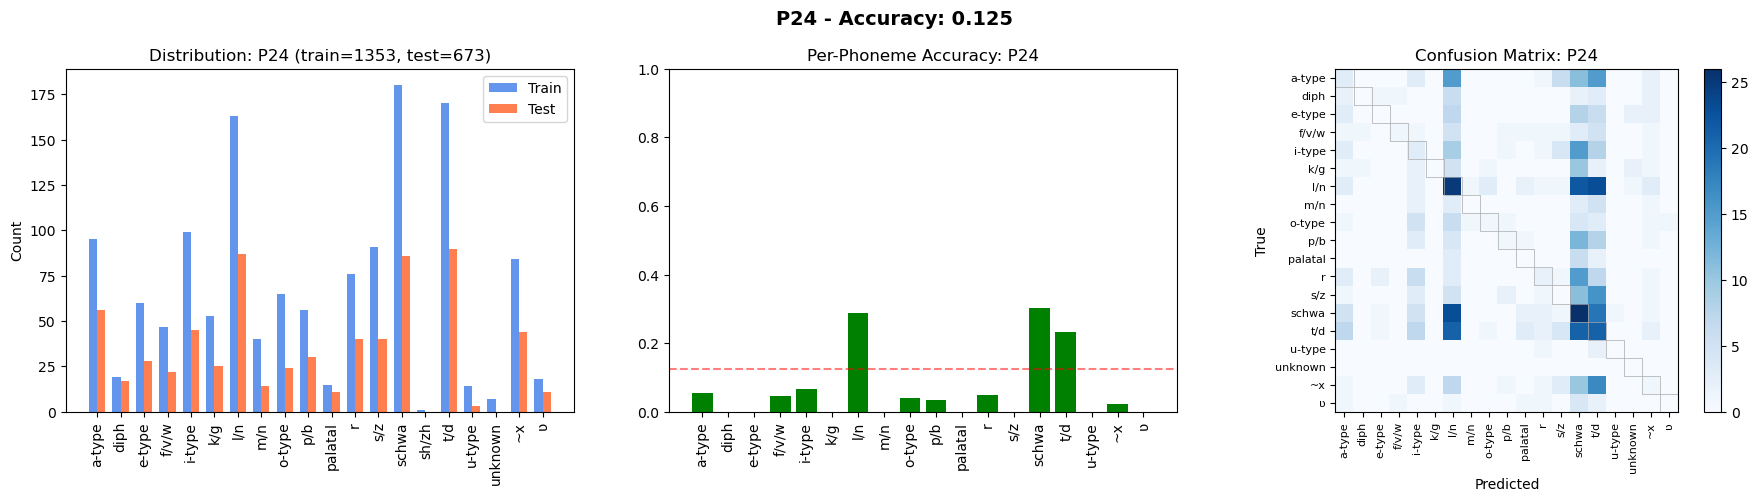


P24 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.05     56  l/n(15), t/d(15), schwa(11)
diph      0.00     17  l/n(6), t/d(3), schwa(2)
e-type    0.00     28  schwa(8), l/n(7), t/d(6)
f/v/w     0.05     22  t/d(5), l/n(5), schwa(3)
i-type    0.07     45  schwa(15), l/n(9), t/d(8)
k/g       0.00     25  schwa(10), l/n(5), t/d(2)
l/n       0.29     87  t/d(23), schwa(22), o-type(3)
m/n       0.00     14  t/d(5), schwa(3), l/n(3)
o-type    0.04     24  l/n(6), i-type(5), schwa(4)
p/b       0.03     30  schwa(12), t/d(8), l/n(4)
palatal   0.00     11  schwa(6), l/n(3), t/d(2)
r         0.05     40  schwa(15), t/d(7), i-type(6)
s/z       0.00     40  t/d(16), schwa(11), l/n(5)
schwa     0.30     86  l/n(23), t/d(19), a-type(5)
t/d       0.23     90  schwa(21), l/n(21), a-type(7)
u-type    0.00      3  t/d(2), r(1)
~x        0.02     44  t/d(17), schwa(10), l/n(7)
ʋ         0.00     11  schw

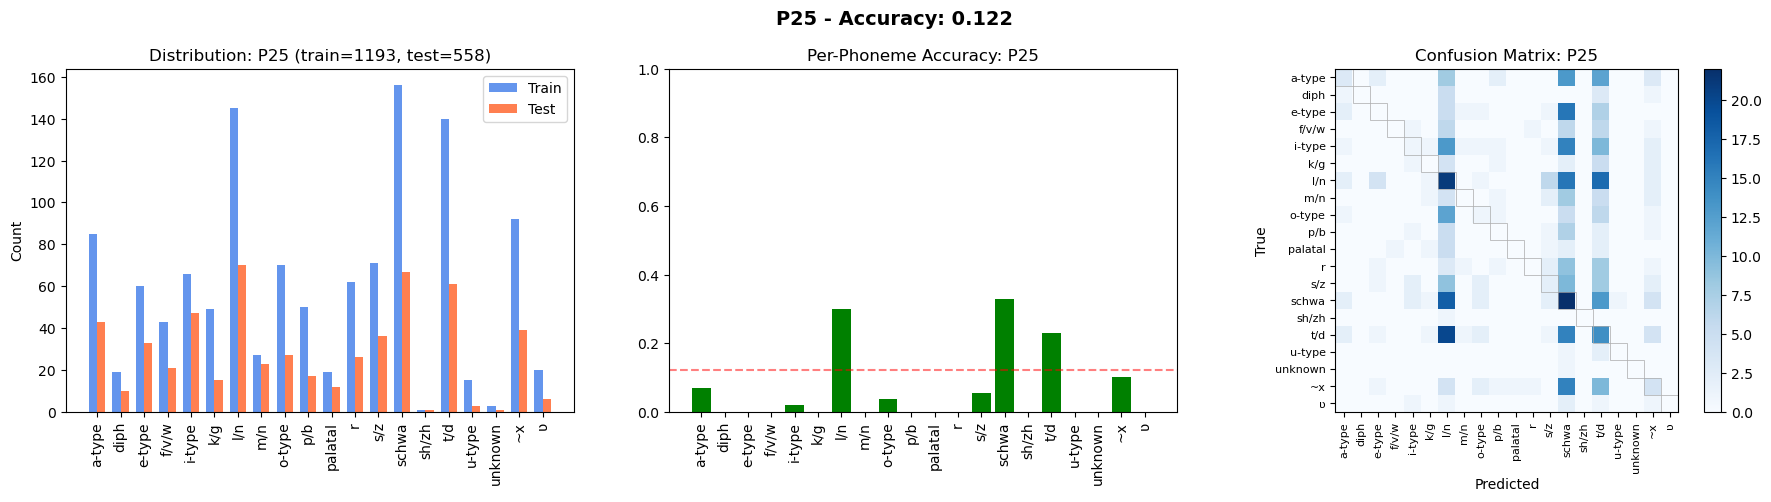


P25 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.07     43  schwa(13), t/d(12), l/n(8)
diph      0.00     10  l/n(5), t/d(3), a-type(1)
e-type    0.00     33  schwa(16), t/d(7), l/n(5)
f/v/w     0.00     21  schwa(6), l/n(6), t/d(6)
i-type    0.02     47  schwa(15), l/n(13), t/d(10)
k/g       0.00     15  t/d(5), l/n(4), schwa(2)
l/n       0.30     70  t/d(17), schwa(16), s/z(6)
m/n       0.00     23  schwa(8), t/d(5), l/n(4)
o-type    0.04     27  l/n(12), t/d(6), schwa(5)
p/b       0.00     17  schwa(7), l/n(5), t/d(2)
palatal   0.00     12  l/n(5), schwa(2), t/d(2)
r         0.00     26  schwa(9), t/d(8), l/n(3)
s/z       0.06     36  schwa(10), l/n(9), t/d(8)
schwa     0.33     67  l/n(18), t/d(13), ~x(4)
sh/zh     0.00      1  l/n(1)
t/d       0.23     61  l/n(20), schwa(15), ~x(4)
u-type    0.00      3  t/d(2), schwa(1)
unknown   0.00      1  schwa(1)
~x        0.10     39  schwa

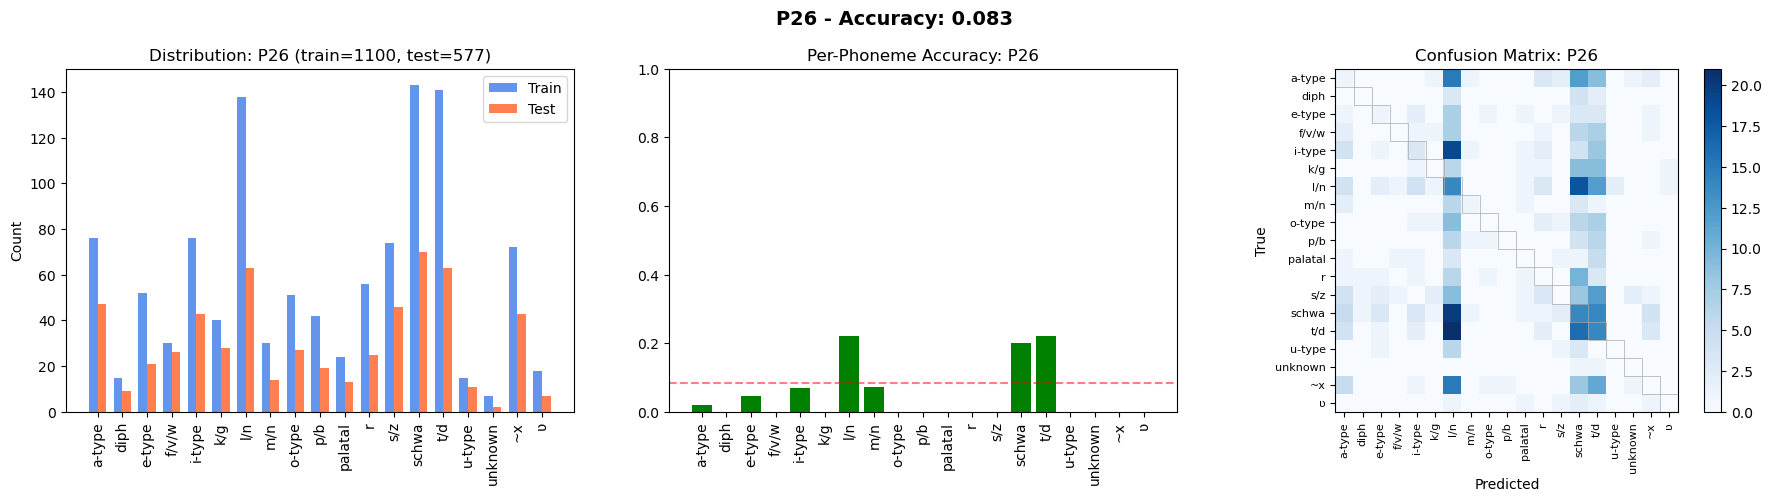


P26 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.02     47  l/n(15), schwa(12), t/d(9)
diph      0.00      9  schwa(4), l/n(3), t/d(2)
e-type    0.05     21  l/n(7), schwa(3), t/d(3)
f/v/w     0.00     26  l/n(7), t/d(7), schwa(6)
i-type    0.07     43  l/n(19), t/d(8), a-type(4)
k/g       0.00     28  schwa(9), t/d(9), l/n(6)
l/n       0.22     63  schwa(18), t/d(12), a-type(4)
m/n       0.07     14  l/n(6), schwa(3), a-type(2)
o-type    0.00     27  l/n(9), t/d(7), schwa(6)
p/b       0.00     19  l/n(6), t/d(6), schwa(4)
palatal   0.00     13  t/d(5), l/n(3), a-type(1)
r         0.00     25  schwa(10), l/n(6), t/d(3)
s/z       0.00     46  t/d(12), l/n(9), schwa(8)
schwa     0.20     70  l/n(20), t/d(14), a-type(5)
t/d       0.22     63  l/n(21), schwa(16), a-type(4)
u-type    0.00     11  l/n(6), schwa(3), e-type(1)
unknown   0.00      2  t/d(1), schwa(1)
~x        0.00     43  l/n(

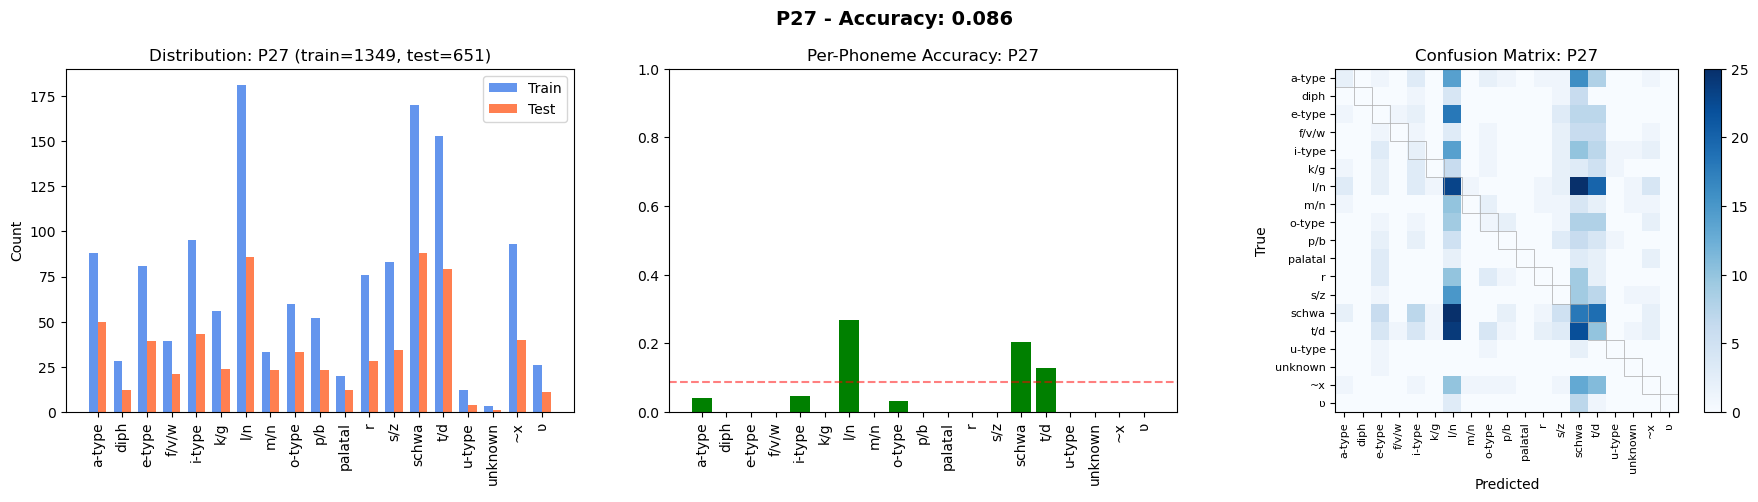


P27 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.04     50  schwa(16), l/n(14), t/d(8)
diph      0.00     12  schwa(6), l/n(4), i-type(1)
e-type    0.00     39  l/n(18), t/d(7), schwa(7)
f/v/w     0.00     21  schwa(6), t/d(6), l/n(3)
i-type    0.05     43  l/n(14), schwa(10), t/d(7)
k/g       0.00     24  l/n(6), t/d(5), schwa(3)
l/n       0.27     86  schwa(25), t/d(20), ~x(4)
m/n       0.00     23  l/n(10), schwa(4), o-type(2)
o-type    0.03     33  l/n(9), schwa(8), t/d(8)
p/b       0.00     23  schwa(6), l/n(5), t/d(4)
palatal   0.00     12  schwa(3), e-type(3), l/n(2)
r         0.00     28  l/n(10), schwa(9), o-type(3)
s/z       0.00     34  l/n(15), schwa(9), t/d(7)
schwa     0.20     88  l/n(25), t/d(19), i-type(7)
t/d       0.13     79  l/n(24), schwa(22), i-type(4)
u-type    0.00      4  schwa(2), o-type(1), e-type(1)
unknown   0.00      1  e-type(1)
~x        0.00     40  sc

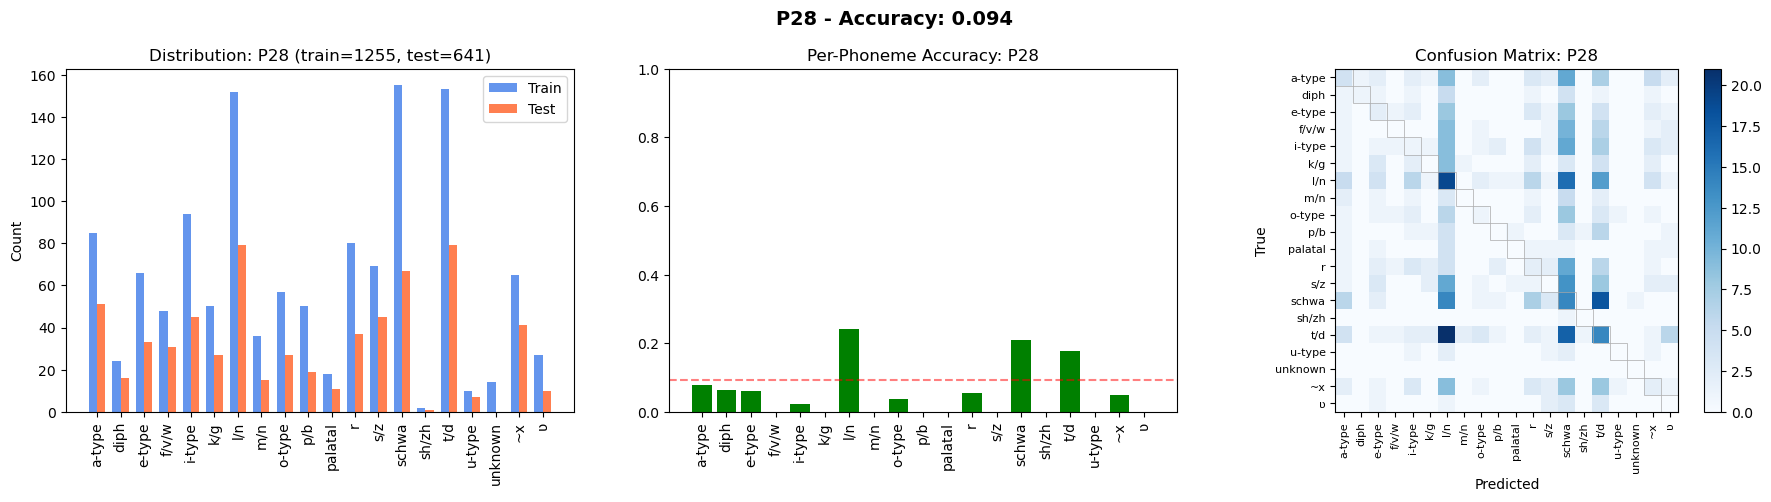


P28 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.08     51  schwa(11), l/n(9), t/d(7)
diph      0.06     16  l/n(5), schwa(4), t/d(1)
e-type    0.06     33  schwa(8), l/n(8), t/d(4)
f/v/w     0.00     31  schwa(10), l/n(9), t/d(6)
i-type    0.02     45  schwa(11), l/n(9), t/d(7)
k/g       0.00     27  l/n(9), t/d(4), schwa(3)
l/n       0.24     79  schwa(16), t/d(12), r(6)
m/n       0.00     15  schwa(5), l/n(3), a-type(2)
o-type    0.04     27  schwa(8), l/n(6), t/d(3)
p/b       0.00     19  t/d(6), l/n(4), schwa(3)
palatal   0.00     11  l/n(4), s/z(1), a-type(1)
r         0.05     37  schwa(11), t/d(6), l/n(4)
s/z       0.00     45  schwa(13), l/n(11), t/d(8)
schwa     0.21     67  t/d(18), l/n(14), r(7)
sh/zh     0.00      1  schwa(1)
t/d       0.18     79  l/n(21), schwa(17), ʋ(6)
u-type    0.00      7  l/n(2), schwa(2), i-type(1)
~x        0.05     41  l/n(9), t/d(8), schwa(8)
ʋ 

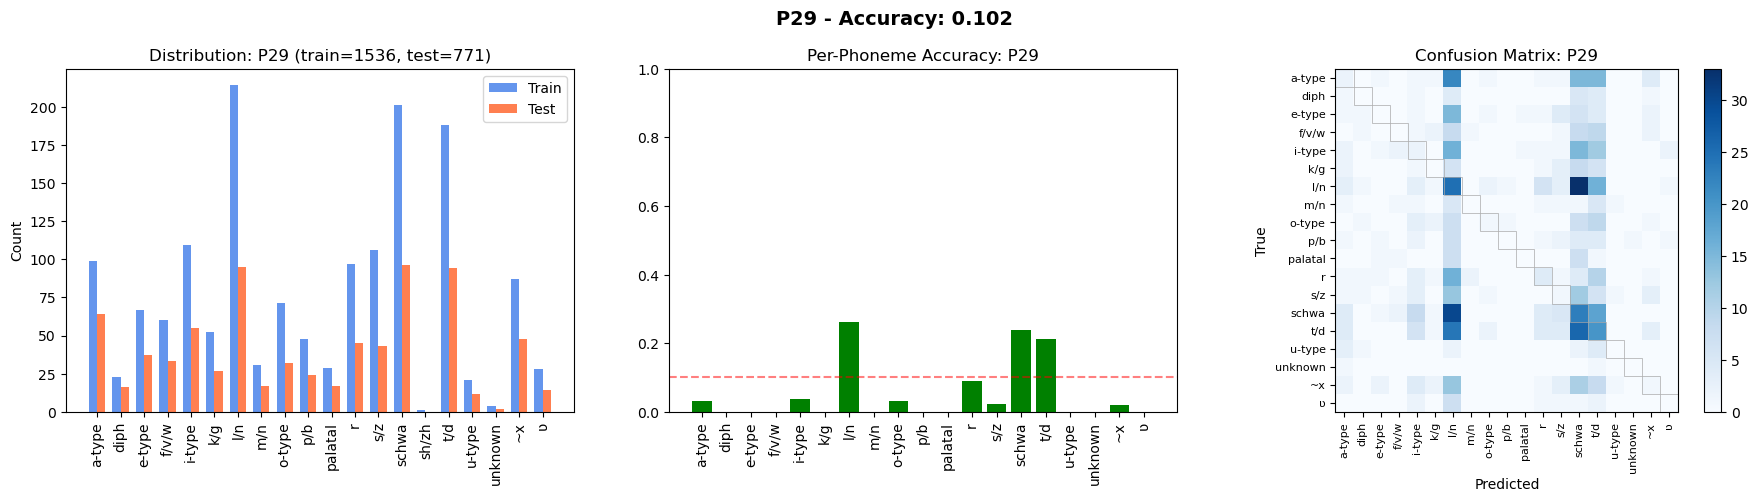


P29 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.03     64  l/n(22), schwa(15), t/d(15)
diph      0.00     16  schwa(5), l/n(4), t/d(4)
e-type    0.00     37  l/n(15), schwa(6), s/z(4)
f/v/w     0.00     33  t/d(9), schwa(8), l/n(8)
i-type    0.04     55  l/n(16), schwa(15), t/d(12)
k/g       0.00     27  schwa(8), l/n(6), t/d(6)
l/n       0.26     95  schwa(33), t/d(16), r(6)
m/n       0.00     17  l/n(5), t/d(5), a-type(1)
o-type    0.03     32  t/d(9), l/n(7), schwa(7)
p/b       0.00     24  l/n(7), schwa(4), t/d(4)
palatal   0.00     17  schwa(7), l/n(7), f/v/w(1)
r         0.09     45  l/n(16), t/d(10), schwa(4)
s/z       0.02     43  l/n(13), schwa(12), t/d(6)
schwa     0.24     96  l/n(30), t/d(18), i-type(8)
t/d       0.21     94  schwa(26), l/n(24), i-type(6)
u-type    0.00     12  t/d(4), a-type(3), l/n(2)
unknown   0.00      2  t/d(1), a-type(1)
~x        0.02     48  l/n(13

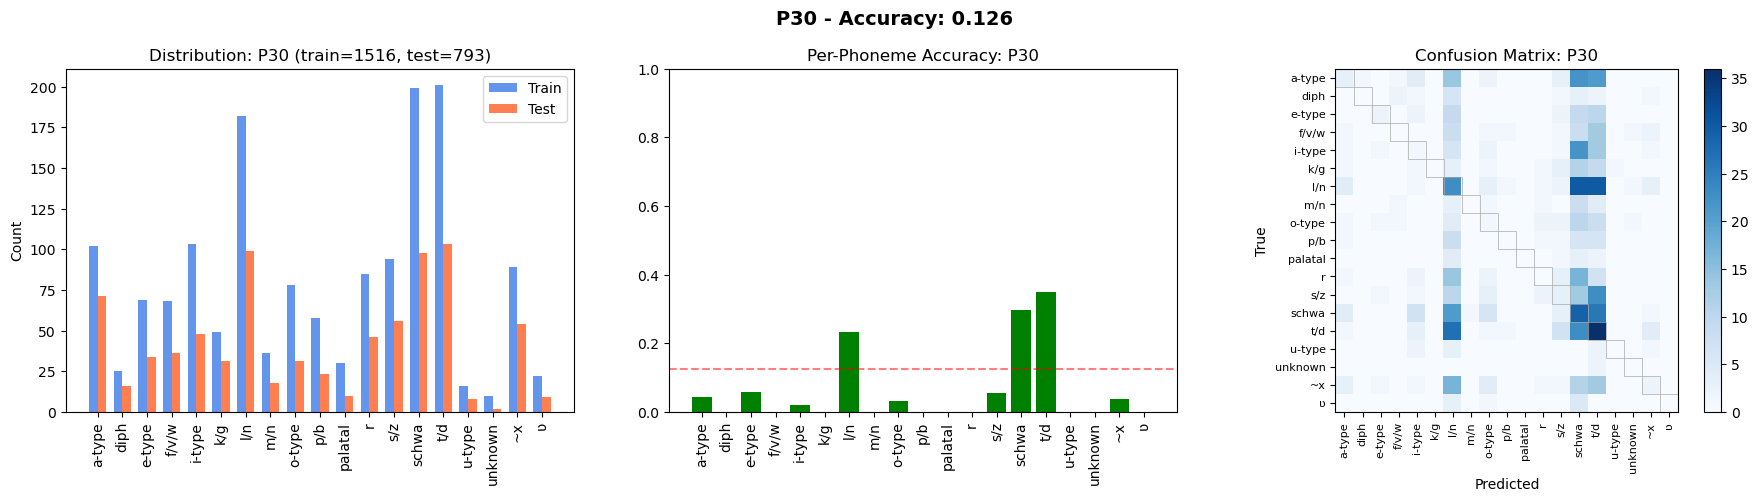


P30 - PER-PHONEME ACCURACY
Phoneme  Acc    Count  Top 3 Confusions
----------------------------------------------------------------------
a-type    0.04     71  schwa(22), t/d(21), l/n(14)
diph      0.00     16  l/n(6), schwa(3), t/d(2)
e-type    0.06     34  t/d(10), schwa(9), l/n(9)
f/v/w     0.00     36  t/d(13), schwa(8), l/n(8)
i-type    0.02     48  schwa(22), t/d(13), l/n(6)
k/g       0.00     31  schwa(11), t/d(9), s/z(3)
l/n       0.23     99  schwa(30), t/d(30), a-type(4)
m/n       0.00     18  schwa(8), t/d(4), l/n(3)
o-type    0.03     31  schwa(10), t/d(8), l/n(4)
p/b       0.00     23  l/n(8), t/d(6), schwa(6)
palatal   0.00     10  l/n(4), schwa(3), t/d(2)
r         0.00     46  schwa(17), l/n(14), t/d(7)
s/z       0.05     56  t/d(23), schwa(13), l/n(10)
schwa     0.30     98  t/d(26), l/n(21), i-type(7)
t/d       0.35    103  l/n(27), schwa(23), s/z(7)
u-type    0.00      8  l/n(3), t/d(2), i-type(2)
unknown   0.00      2  t/d(2)
~x        0.04     54  l/n(17), t/d(13

In [27]:
for pid in sorted(grouped_results.keys()):
    visualize_patient_model(pid, grouped_results, pipeline)

In [39]:
import warnings
warnings.filterwarnings('ignore', message='.*number of unique classes.*')

In [33]:
def diagnose_feature_quality(pipeline, n_phonemes_to_check=10):
    """
    Check if features show ANY systematic differences between phonemes.
    """
    import numpy as np
    from collections import defaultdict, Counter
    from scipy.stats import ttest_ind
    import matplotlib.pyplot as plt
    
    phoneme_features = defaultdict(list)
    
    for feat, label in zip(pipeline.train['features'], pipeline.train['phoneme_labels']):
        if label == '?' or label == 'unknown':
            continue
        if feat.ndim > 1:
            feat_flat = np.mean(feat, axis=0)
        else:
            feat_flat = feat
        if not np.any(np.isnan(feat_flat)) and not np.any(np.isinf(feat_flat)):
            phoneme_features[label].append(feat_flat)
    
    # Filter to consistent shapes per phoneme
    phoneme_features_clean = {}
    
    for phoneme, features in phoneme_features.items():
        shape_counts = Counter(f.shape[0] for f in features)
        if not shape_counts:
            continue
        most_common_len = max(shape_counts, key=shape_counts.get)
        filtered = [f for f in features if f.shape[0] == most_common_len]
        
        if len(filtered) >= 10:
            phoneme_features_clean[phoneme] = np.array(filtered)
    
    print(f"Phonemes with consistent features: {len(phoneme_features_clean)}")
    
    # Get phonemes with most samples
    sorted_phonemes = sorted(phoneme_features_clean.keys(), key=lambda x: -len(phoneme_features_clean[x]))
    top_phonemes = sorted_phonemes[:n_phonemes_to_check]
    
    print(f"Top {len(top_phonemes)} phonemes by sample count:")
    for p in top_phonemes:
        print(f"  {p}: {len(phoneme_features_clean[p])} samples, {phoneme_features_clean[p].shape[1]} features")
    
    print("\nChecking feature separability between top phonemes:")
    print("=" * 70)
    
    pair_results = []
    
    for i, p1 in enumerate(top_phonemes):
        for p2 in top_phonemes[i+1:]:
            features_p1 = phoneme_features_clean[p1]
            features_p2 = phoneme_features_clean[p2]
            
            # Ensure same feature dimension
            min_dim = min(features_p1.shape[1], features_p2.shape[1])
            features_p1 = features_p1[:, :min_dim]
            features_p2 = features_p2[:, :min_dim]
            
            # Count significant features
            n_significant = 0
            for feat_idx in range(min_dim):
                stat, pval = ttest_ind(features_p1[:, feat_idx], features_p2[:, feat_idx])
                if pval < 0.01:
                    n_significant += 1
            
            pct_significant = n_significant / min_dim * 100
            pair_results.append((p1, p2, pct_significant, len(phoneme_features_clean[p1]), len(phoneme_features_clean[p2])))
    
    # Sort by percentage of significant features
    pair_results.sort(key=lambda x: -x[2])
    
    print(f"\n{'Phoneme 1':<10} {'Phoneme 2':<10} {'% Sig. Features':<15} {'N1':<6} {'N2':<6}")
    print("-" * 70)
    
    for p1, p2, pct, n1, n2 in pair_results[:20]:
        print(f"{p1:<10} {p2:<10} {pct:<15.1f} {n1:<6} {n2:<6}")
    
    # Summary
    avg_pct = np.mean([x[2] for x in pair_results])
    print(f"\nAverage % significant features across all pairs: {avg_pct:.1f}%")
    
    if avg_pct < 5:
        print("\nDIAGNOSIS: Very few features differ between phonemes.")
        print("  -> Features may not capture phoneme-relevant information")
        print("  -> Consider: different frequency bands, different time windows, electrode selection")
    elif avg_pct < 15:
        print("\nDIAGNOSIS: Weak but present differences between phonemes.")
        print("  -> Some signal exists but may need feature engineering")
    else:
        print("\nDIAGNOSIS: Moderate feature differences exist.")
        print("  -> Classification should be possible with right approach")
    
    # Visualize the best-separable pair
    if pair_results:
        best_pair = pair_results[0]
        p1, p2 = best_pair[0], best_pair[1]
        
        features_p1 = phoneme_features_clean[p1]
        features_p2 = phoneme_features_clean[p2]
        min_dim = min(features_p1.shape[1], features_p2.shape[1])
        features_p1 = features_p1[:, :min_dim]
        features_p2 = features_p2[:, :min_dim]
        
        # Find the two most discriminative features
        t_stats = []
        for feat_idx in range(min_dim):
            stat, pval = ttest_ind(features_p1[:, feat_idx], features_p2[:, feat_idx])
            t_stats.append(abs(stat))
        
        best_feat_indices = np.argsort(t_stats)[-2:]
        
        fig, ax = plt.subplots(figsize=(8, 6))
        
        ax.scatter(
            features_p1[:, best_feat_indices[0]], 
            features_p1[:, best_feat_indices[1]], 
            alpha=0.5, label=f"'{p1}' (n={len(features_p1)})"
        )
        ax.scatter(
            features_p2[:, best_feat_indices[0]], 
            features_p2[:, best_feat_indices[1]], 
            alpha=0.5, label=f"'{p2}' (n={len(features_p2)})"
        )
        
        ax.set_xlabel(f'Feature {best_feat_indices[0]}')
        ax.set_ylabel(f'Feature {best_feat_indices[1]}')
        ax.set_title(f'Best Separable Pair: {p1} vs {p2}\n({best_pair[2]:.1f}% features significantly different)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return pair_results

Phonemes with consistent features: 18
Top 15 phonemes by sample count:
  l/n: 983 samples, 130 features
  schwa: 953 samples, 130 features
  t/d: 930 samples, 130 features
  a-type: 521 samples, 130 features
  i-type: 511 samples, 130 features
  s/z: 461 samples, 130 features
  ~x: 460 samples, 130 features
  r: 437 samples, 130 features
  o-type: 391 samples, 130 features
  e-type: 353 samples, 130 features
  k/g: 319 samples, 130 features
  p/b: 299 samples, 130 features
  f/v/w: 275 samples, 130 features
  m/n: 205 samples, 130 features
  diph: 145 samples, 130 features

Checking feature separability between top phonemes:

Phoneme 1  Phoneme 2  % Sig. Features N1     N2    
----------------------------------------------------------------------
~x         diph       20.0            460    145   
l/n        ~x         18.5            983    460   
f/v/w      diph       13.8            275    145   
l/n        t/d        13.1            983    930   
t/d        diph       13.1         

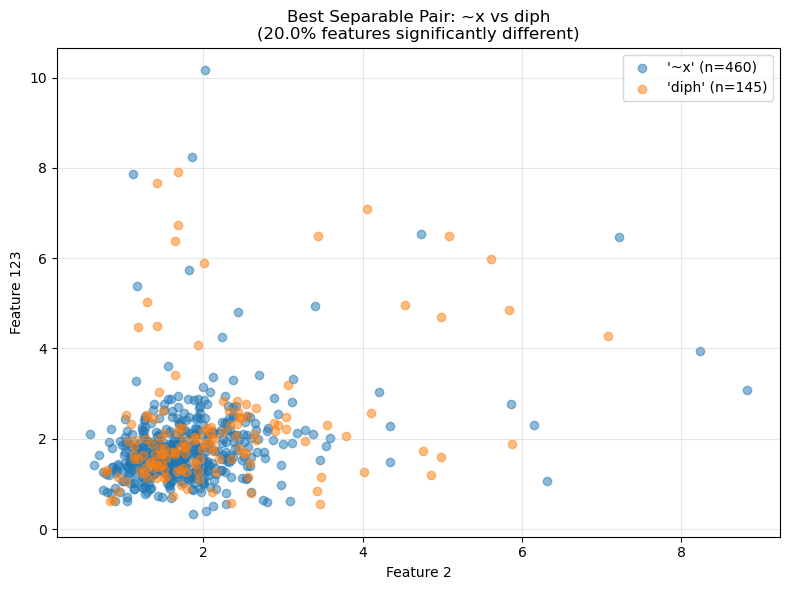

In [34]:
pair_results = diagnose_feature_quality(pipeline, n_phonemes_to_check=15)

In [39]:
def train_and_evaluate_extended(pipeline, use_groups=False, method='markov'):
    """
    Train per patient with multiple approaches.
    
    Args:
        pipeline: Dutch30Pipeline with loaded data
        use_groups: Whether to use phoneme groups
        method: One of 'markov', 'gmm', 'soft_labels', 'gmm_informed'
    """
    import numpy as np
    from sklearn.mixture import GaussianMixture
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.metrics import accuracy_score
    from scipy.special import softmax
    from markov_phoneme_model import MarkovPhonemeModel
    
    results = {}
    
    for pid in sorted(set(pipeline.train['phoneme_participant_ids'])):
        train_mask = [p == pid for p in pipeline.train['phoneme_participant_ids']]
        test_mask = [p == pid for p in pipeline.test['phoneme_participant_ids']]
        
        train_feat = [pipeline.train['features'][i] for i, m in enumerate(train_mask) if m]
        train_labels = [pipeline.train['phoneme_labels'][i] for i, m in enumerate(train_mask) if m]
        test_feat = [pipeline.test['features'][i] for i, m in enumerate(test_mask) if m]
        test_labels = [pipeline.test['phoneme_labels'][i] for i, m in enumerate(test_mask) if m]
        
        if len(train_feat) < 10 or len(test_feat) < 5:
            continue
        
        X_train = []
        for feat in train_feat:
            if feat.ndim > 1:
                X_train.append(np.mean(feat, axis=0))
            else:
                X_train.append(feat)
        X_train = np.array(X_train)
        
        X_test = []
        for feat in test_feat:
            if feat.ndim > 1:
                X_test.append(np.mean(feat, axis=0))
            else:
                X_test.append(feat)
        X_test = np.array(X_test)
        
        valid_train = ~(np.isnan(X_train).any(axis=1) | np.isinf(X_train).any(axis=1))
        valid_test = ~(np.isnan(X_test).any(axis=1) | np.isinf(X_test).any(axis=1))
        
        X_train = X_train[valid_train]
        y_train = [train_labels[i] for i in range(len(train_labels)) if valid_train[i]]
        X_test = X_test[valid_test]
        y_test = [test_labels[i] for i in range(len(test_labels)) if valid_test[i]]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        n_classes = len(le.classes_)
        
        if method == 'markov':
            model = MarkovPhonemeModel(
                phonetic_dict=pipeline.detector.phonetic_dict,
                order=1,
                use_groups=use_groups
            )
            train_feat_valid = [train_feat[i] for i in range(len(train_feat)) if valid_train[i]]
            model.train(features=train_feat_valid, phoneme_labels=y_train)
            
            test_feat_valid = [test_feat[i] for i in range(len(test_feat)) if valid_test[i]]
            preds, _ = model.predict(test_feat_valid, use_viterbi=True)
            accuracy = sum(1 for p, t in zip(preds, y_test) if p == t) / len(y_test)
            
        elif method == 'gmm':
            gmm_per_class = {}
            for class_idx in range(n_classes):
                class_mask = y_train_encoded == class_idx
                if np.sum(class_mask) < 2:
                    continue
                
                X_class = X_train_scaled[class_mask]
                n_components = min(3, len(X_class) // 2)
                if n_components < 1:
                    n_components = 1
                
                gmm = GaussianMixture(
                    n_components=n_components,
                    covariance_type='diag',
                    max_iter=100,
                    random_state=42
                )
                gmm.fit(X_class)
                gmm_per_class[class_idx] = gmm
            
            preds_encoded = []
            for x in X_test_scaled:
                scores = []
                for class_idx in range(n_classes):
                    if class_idx in gmm_per_class:
                        score = gmm_per_class[class_idx].score_samples(x.reshape(1, -1))[0]
                    else:
                        score = -np.inf
                    scores.append(score)
                preds_encoded.append(np.argmax(scores))
            
            preds = le.inverse_transform(preds_encoded)
            accuracy = accuracy_score(y_test, preds)
            
        elif method == 'soft_labels':
            from sklearn.ensemble import RandomForestClassifier
            
            soft_targets = np.zeros((len(y_train_encoded), n_classes))
            smoothing = 0.1
            
            for i, label in enumerate(y_train_encoded):
                soft_targets[i, :] = smoothing / n_classes
                soft_targets[i, label] = 1.0 - smoothing + smoothing / n_classes
            
            rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
            rf.fit(X_train_scaled, y_train_encoded)
            
            preds_encoded = rf.predict(X_test_scaled)
            preds = le.inverse_transform(preds_encoded)
            accuracy = accuracy_score(y_test, preds)
            
        elif method == 'gmm_informed':
            n_components_total = min(n_classes * 2, 20)
            
            gmm_unsupervised = GaussianMixture(
                n_components=n_components_total,
                covariance_type='diag',
                max_iter=100,
                random_state=42
            )
            gmm_unsupervised.fit(X_train_scaled)
            
            cluster_probs = gmm_unsupervised.predict_proba(X_train_scaled)
            
            X_augmented_train = np.hstack([X_train_scaled, cluster_probs])
            X_augmented_test = np.hstack([
                X_test_scaled, 
                gmm_unsupervised.predict_proba(X_test_scaled)
            ])
            
            from sklearn.ensemble import RandomForestClassifier
            rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
            rf.fit(X_augmented_train, y_train_encoded)
            
            preds_encoded = rf.predict(X_augmented_test)
            preds = le.inverse_transform(preds_encoded)
            accuracy = accuracy_score(y_test, preds)
        
        results[pid] = {
            'accuracy': accuracy,
            'train_size': len(X_train),
            'test_size': len(X_test),
            'n_classes': n_classes,
            'predictions': preds,
            'true_labels': y_test
        }
        
        print(f"  {pid}: Acc={accuracy:.3f} (method={method}, classes={n_classes}, train={len(X_train)})")
    
    accs = [r['accuracy'] for r in results.values()]
    print(f"\n  Mean: {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
    
    return results


def compare_methods(pipeline, use_groups=False):
    """Compare all methods side by side."""
    import pandas as pd
    
    methods = ['markov', 'gmm', 'soft_labels', 'gmm_informed']
    all_results = {}
    
    for method in methods:
        print(f"\n{'='*60}")
        print(f"METHOD: {method}")
        print('='*60)
        all_results[method] = train_and_evaluate_extended(pipeline, use_groups, method)
    
    comparison = {}
    for method, results in all_results.items():
        for pid, res in results.items():
            if pid not in comparison:
                comparison[pid] = {}
            comparison[pid][method] = res['accuracy']
    
    df = pd.DataFrame(comparison).T
    df['Max'] = df.max(axis=1)
    df['Best'] = df.idxmax(axis=1)
    
    print("\n" + "="*80)
    print("COMPARISON TABLE")
    print("="*80)
    print(df.to_string())
    
    print("\n" + "="*80)
    print("MEAN ACCURACY BY METHOD")
    print("="*80)
    for method in methods:
        accs = [comparison[pid].get(method, np.nan) for pid in comparison]
        print(f"  {method:15s}: {np.nanmean(accs):.3f} +/- {np.nanstd(accs):.3f}")
    
    return all_results, df

In [18]:
# all_results, comparison_df = compare_methods(pipeline, use_groups=True)